# RetailHero Exploratory Data Analysis

## Objective

This notebook explores the cleaned RetailHero data to support feature engineering for uplift modeling.

The modeling population is defined by `uplift_train`, which contains the customers with observed treatment assignment and purchase outcome. Customer information, purchase history, and product metadata are restricted to this population before the analysis begins.

The analysis follows this workflow:

```text
Cleaned RetailHero data
        ↓
Define experiment population
        ↓
Experiment sanity check
        ↓
Broad data overview
        ↓
Customer-level behavioral EDA
        ↓
Treatment-Control analysis
        ↓
Feature-engineering implications

### RetailHero Data Structure

The cleaned RetailHero data consists of four tables:

- `clients`: customer information
- `products`: product metadata
- `purchases`: historical purchases recorded before the promotional communication
- `uplift_train`: treatment assignment and observed outcome for the labeled experiment customers

The tables are connected through `client_id` and `product_id`.

```text
uplift_train
      │
      │ client_id
      ▼
   clients

uplift_train
      │
      │ client_id
      ▼
  purchases ─── product_id ───► products
```

The final modeling decision is made at the customer level. Purchase and product tables therefore remain at their original grain during exploration and are aggregated to customer-level features only when needed.

## Data Overview

### Table and Column Description

The competition documentation describes the purpose of each table but does not provide a complete business definition for every raw field.

The descriptions below are therefore working interpretations based on the available documentation, column names, and observed table structure. Fields whose exact semantics remain unclear are kept explicit rather than assigned an unsupported business meaning.


### `clients`

One row is expected to represent one customer.

| Column              | Description                                                        |
| ------------------- | ------------------------------------------------------------------ |
| `client_id`         | Unique customer identifier used to link tables                     |
| `first_issue_date`  | Date associated with the customer's first loyalty-card issuance    |
| `first_redeem_date` | Date associated with the customer's first loyalty-point redemption |
| `age`               | Customer age                                                       |
| `gender`            | Customer gender                                                    |

### `products`

One row is expected to represent one product.

| Column             | Description                                             |
| ------------------ | ------------------------------------------------------- |
| `product_id`       | Unique product identifier used to link purchase records |
| `level_1`          | Highest-level product category                          |
| `level_2`          | Second-level product category                           |
| `level_3`          | Third-level product category                            |
| `level_4`          | Most detailed product category provided                 |
| `segment_id`       | Product segment identifier                              |
| `brand_id`         | Brand identifier                                        |
| `vendor_id`        | Vendor or supplier identifier                           |
| `netto`            | Numeric product attribute provided by RetailHero                                |
| `is_own_trademark` | Whether the product belongs to the retailer's own brand |
| `is_alcohol`       | Whether the product is alcoholic                        |

### `purchases`

The table contains customer purchase history recorded before the promotional communication.

The initial working assumption is that each row represents a product line within a transaction. This assumption is validated later because a transaction may contain multiple products and `transaction_id` is not assumed to be globally unique without verification.


| Column                    | Description                                                          |
| ------------------------- | -------------------------------------------------------------------- |
| `client_id`               | Customer associated with the transaction                             |
| `transaction_id`          | Transaction or receipt identifier                                    |
| `transaction_datetime`    | Date and time of the transaction                                     |
| `regular_points_received` | Regular loyalty points received                                      |
| `express_points_received` | Express loyalty points received                                      |
| `regular_points_spent`    | Regular loyalty points redeemed                                      |
| `express_points_spent`    | Express loyalty points redeemed                                      |
| `purchase_sum`            | Purchase amount recorded for the transaction                         |
| `store_id`                | Store identifier                                                     |
| `product_id`              | Purchased product identifier                                         |
| `product_quantity`        | Quantity of the product purchased                                    |
| `trn_sum_from_iss`        | Amount associated with the product line on the point-issuance side   |


The exact business rules behind `express_points_*`, `trn_sum_from_iss`, and `trn_sum_from_red` are not documented in detail in the available competition description.


### `uplift_train`

One row is expected to represent one customer in the labeled uplift experiment.

| Column          | Description                                                                    |
| --------------- | ------------------------------------------------------------------------------ |
| `client_id`     | Customer identifier used to join with customer and purchase data               |
| `treatment_flg` | Treatment assignment: `1` if promotional communication was sent, otherwise `0` |
| `target`        | Binary outcome indicating whether the customer made a purchase afterward       |

For this experiment:

```text
treatment = treatment_flg
outcome   = target
```

The remaining tables provide information that can potentially be transformed into **pre-treatment customer features**, while `uplift_train` determines the treatment and observed outcome for each modeled customer.


In [443]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


In [444]:
TABLE_HIGHLIGHT = {
    "blue": {"background-color": "#1976D2", "color": "white", "font-weight": "700"},
    "red": {"background-color": "#D32F2F", "color": "white", "font-weight": "700"},
}

COLORS = {
    "pacific_green": "#017360",
    "rainy_lake": "#446E8F",
    "serene_sea": "#77A7C4",
    "sora_blue": "#A1DBF1",
    "afterglow": "#F2E6CE",
    "bungalow_maple": "#F3D094",
}


def style_table(df: pd.DataFrame, formats: dict | None = None):
    return df.style.hide(axis="index").format(formats or {}, na_rep="—")


def paint(styler, rows, columns, style_key: str):
    rows = list(rows)
    if not rows:
        return styler

    columns = [columns] if isinstance(columns, str) else list(columns)
    return styler.set_properties(
        subset=pd.IndexSlice[rows, columns],
        **TABLE_HIGHLIGHT[style_key],
    )


plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [445]:
PROJECT_ROOT = Path.cwd().parents[1]

INTERIM_DATA_DIR = PROJECT_ROOT / "data" / "interim" / "retailhero"
CLEAN_DATA_DIR = INTERIM_DATA_DIR / "clean"

CLEAN_FILES = {
    "clients": CLEAN_DATA_DIR / "clients_clean.parquet",
    "products": CLEAN_DATA_DIR / "products_clean.parquet",
    "purchases": CLEAN_DATA_DIR / "purchases_clean.parquet",
    "uplift_train": CLEAN_DATA_DIR / "uplift_train_clean.parquet",
}

missing_files = [
    f"{name}: {path}"
    for name, path in CLEAN_FILES.items()
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "Missing RetailHero cleaned files:\n" + "\n".join(missing_files)
    )

print("Project root:", PROJECT_ROOT)
print("Clean data:", CLEAN_DATA_DIR)

Project root: d:\thao\d\uplif_model\uplif_customer_selection
Clean data: d:\thao\d\uplif_model\uplif_customer_selection\data\interim\retailhero\clean


In [446]:
duckdb_connection = duckdb.connect()

for table_name, path in CLEAN_FILES.items():
    duckdb_connection.execute(
        f"""
        CREATE OR REPLACE VIEW {table_name}_clean AS
        SELECT *
        FROM read_parquet('{path.as_posix()}')
        """
    )

## Define Experiment Population

The labeled uplift experiment is defined by `uplift_train`.

Before starting the EDA, all supporting tables are explicitly restricted to these customers:

- `clients` keeps only experiment customers
- `purchases` keeps only their historical purchases
- `products` keeps only products appearing in those purchase histories.

This creates a consistent analysis scope while preserving the original grain of each table.

In [447]:
duckdb_connection.execute(
    """
    CREATE OR REPLACE VIEW uplift_train AS
    SELECT *
    FROM uplift_train_clean
    """
)

duckdb_connection.execute(
    """
    CREATE OR REPLACE VIEW clients AS
    SELECT c.*
    FROM clients_clean AS c
    INNER JOIN uplift_train AS u USING (client_id)
    """
)

duckdb_connection.execute(
    """
    CREATE OR REPLACE VIEW purchases AS
    SELECT p.*
    FROM purchases_clean AS p
    INNER JOIN uplift_train AS u USING (client_id)
    """
)

duckdb_connection.execute(
    """
    CREATE OR REPLACE VIEW products AS
    SELECT pr.*
    FROM products_clean AS pr
    INNER JOIN (
        SELECT DISTINCT product_id
        FROM purchases
    ) AS p USING (product_id)
    """
)

In [448]:
analysis_relations = {
    "clients": "clients",
    "products": "products",
    "purchases": "purchases",
    "uplift_train": "uplift_train",
}

scope_overview = []

for table_name, relation_name in analysis_relations.items():
    rows = duckdb_connection.execute(
        f"SELECT COUNT(*) FROM {relation_name}"
    ).fetchone()[0]

    columns = len(
        duckdb_connection.execute(
            f"DESCRIBE {relation_name}"
        ).df()
    )

    scope_overview.append({
        "table": table_name,
        "rows": rows,
        "columns": columns,
    })

scope_overview = pd.DataFrame(scope_overview)

display(
    style_table(
        scope_overview,
        formats={"rows": "{:,.0f}"},
    )
)

table,rows,columns
clients,"200,039",5
products,"40,716",11
purchases,"22,882,690",12
uplift_train,"200,039",3


## Experiment Sanity Check

Before exploring customer behavior, first take a quick look at the labeled uplift experiment.

- How customers are divided between Treatment and Control
- How common the positive outcome is
- Whether the observed purchase rate differs between the two groups.

experiment_group,customers,percentage
Control,"100,058",50.02%
Treatment,"99,981",49.98%


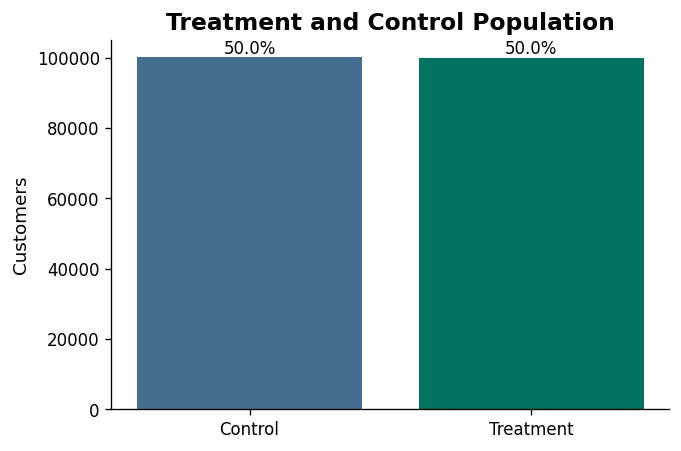

In [449]:
treatment_distribution = duckdb_connection.execute(
    """
    SELECT
        CASE
            WHEN treatment_flg = 0 THEN 'Control'
            WHEN treatment_flg = 1 THEN 'Treatment'
        END AS experiment_group,
        COUNT(*) AS customers,
        100.0 * COUNT(*) / SUM(COUNT(*)) OVER () AS percentage
    FROM uplift_train
    GROUP BY treatment_flg
    ORDER BY treatment_flg
    """
).df()

display(
    style_table(
        treatment_distribution,
        formats={
            "customers": "{:,.0f}",
            "percentage": "{:.2f}%",
        },
    )
)

plt.figure(figsize=(6, 4))

bars = plt.bar(
    treatment_distribution["experiment_group"],
    treatment_distribution["customers"],
    color=[
        COLORS["rainy_lake"],
        COLORS["pacific_green"],
    ],
)

for bar, percentage in zip(
    bars,
    treatment_distribution["percentage"],
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{percentage:.1f}%",
        ha="center",
        va="bottom",
    )

plt.title("Treatment and Control Population")
plt.ylabel("Customers")
plt.show()

experiment_group,customers,positive_outcomes,positive_outcome_rate
Control,"100,058","60,363",60.33%
Treatment,"99,981","63,639",63.65%


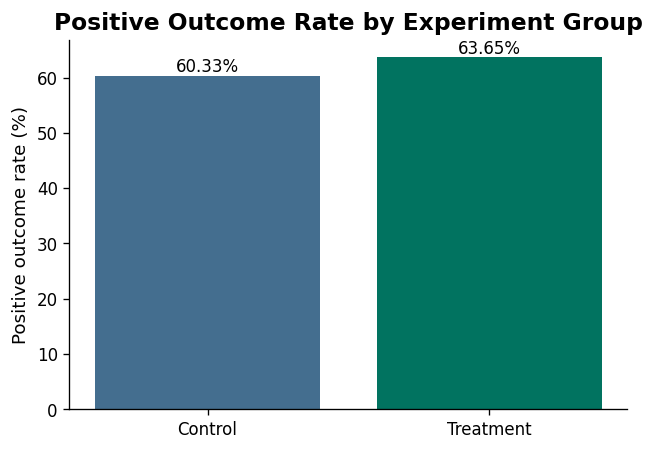

In [450]:
outcome_by_treatment = duckdb_connection.execute(
    """
    SELECT
        CASE
            WHEN treatment_flg = 0 THEN 'Control'
            WHEN treatment_flg = 1 THEN 'Treatment'
        END AS experiment_group,
        COUNT(*) AS customers,
        SUM(target) AS positive_outcomes,
        100.0 * AVG(target) AS positive_outcome_rate
    FROM uplift_train
    GROUP BY treatment_flg
    ORDER BY treatment_flg
    """
).df()

display(
    style_table(
        outcome_by_treatment,
        formats={
            "customers": "{:,.0f}",
            "positive_outcomes": "{:,.0f}",
            "positive_outcome_rate": "{:.2f}%",
        },
    )
)

plt.figure(figsize=(6, 4))

bars = plt.bar(
    outcome_by_treatment["experiment_group"],
    outcome_by_treatment["positive_outcome_rate"],
    color=[
        COLORS["rainy_lake"],
        COLORS["pacific_green"],
    ],
)

for bar, rate in zip(
    bars,
    outcome_by_treatment["positive_outcome_rate"],
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.2f}%",
        ha="center",
        va="bottom",
    )

plt.title("Positive Outcome Rate by Experiment Group")
plt.ylabel("Positive outcome rate (%)")
plt.show()

The start and end timestamps are fixed here and reused consistently in the later customer-level analysis.

In [451]:
analysis_window = duckdb_connection.execute(
    """
    SELECT
        MIN(transaction_datetime) AS analysis_start,
        MAX(transaction_datetime) AS analysis_end
    FROM purchases
    """
).df()

ANALYSIS_START_TIMESTAMP = analysis_window.loc[0, "analysis_start"]
ANALYSIS_END_TIMESTAMP = analysis_window.loc[0, "analysis_end"]

display(analysis_window)

print("Analysis start:", ANALYSIS_START_TIMESTAMP)
print("Analysis end:", ANALYSIS_END_TIMESTAMP)

,analysis_start,analysis_end
0,2018-11-21 21:02:33,2019-03-18 23:19:28


Analysis start: 2018-11-21 21:02:33
Analysis end: 2019-03-18 23:19:28


### Experiment Overview

The experiment contains **200,039 customers** and is almost evenly split between Control (**50.02%**) and Treatment (**49.98%**).

The positive outcome rate is **60.33% for Control** and **63.65% for Treatment**, giving an observed difference of about **3.3 percentage points**. This suggests that the treatment may have a positive overall effect, while the later analysis will examine whether this effect differs across customer groups.

The available purchase history covers **21 November 2018 to 18 March 2019**. This period is fixed as the pre-treatment analysis window and will be used consistently in the following EDA and feature engineering steps.

### From Purchase Records to Customer Behavior

Before moving to customer behavior, the purchase history needs to be aggregated carefully.

The cleaning analysis showed that:

- One row in `purchases` represents a product line, not a complete transaction
- `transaction_id` alone is not always unique, so a transaction is identified by 
> `client_id + transaction_id + transaction_datetime + store_id`
- `purchase_sum` and loyalty-point fields are transaction-level values and must be counted only once per transaction;
- `product_id`, `product_quantity`, and `trn_sum_from_iss` are product-line values and need to be aggregated within each transaction;
- `trn_sum_from_iss` is kept separate from `purchase_sum` because they represent different quantities.

In [452]:
duckdb_connection.execute(
    """
    CREATE OR REPLACE VIEW transactions AS
    SELECT
        client_id,
        transaction_id,
        transaction_datetime,
        store_id,

        MAX(purchase_sum) AS purchase_sum,

        SUM(product_quantity) AS basket_quantity,
        COUNT(DISTINCT product_id) AS unique_products,
        SUM(trn_sum_from_iss) AS trn_sum_from_iss_total,

        MAX(regular_points_received) AS regular_points_received,
        MAX(express_points_received) AS express_points_received,
        MAX(regular_points_spent) AS regular_points_spent,
        MAX(express_points_spent) AS express_points_spent

    FROM purchases

    GROUP BY
        client_id,
        transaction_id,
        transaction_datetime,
        store_id
    """
)

## Broad Data Overview

Before analyzing customer behavior in detail, first take a simple look at the scale and composition of the available data.


In [453]:
dataset_overview = duckdb_connection.execute(
    """
    SELECT
        (SELECT COUNT(*) FROM clients) AS customers,
        (SELECT COUNT(*) FROM transactions) AS transactions,
        (SELECT COUNT(*) FROM purchases) AS purchase_lines,
        (SELECT COUNT(*) FROM products) AS products,
        (SELECT COUNT(DISTINCT store_id) FROM transactions) AS stores
    """
).df()

display(
    style_table(
        dataset_overview,
        formats={
            "customers": "{:,.0f}",
            "transactions": "{:,.0f}",
            "purchase_lines": "{:,.0f}",
            "products": "{:,.0f}",
            "stores": "{:,.0f}",
        },
    )
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

customers,transactions,purchase_lines,products,stores
"200,039","4,024,949","22,882,690","40,716","13,879"


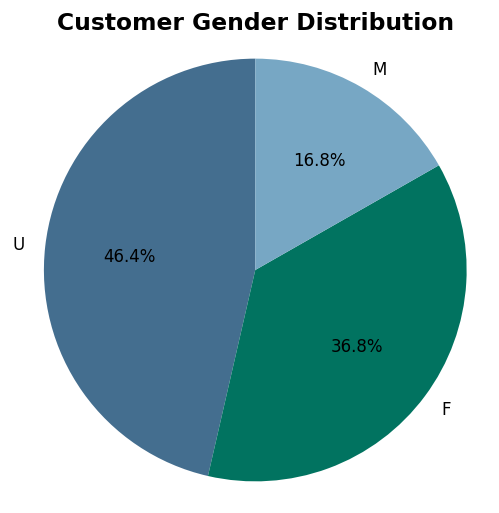

In [454]:
gender_distribution = duckdb_connection.execute(
    """
    SELECT
        gender,
        COUNT(*) AS customers,
        100.0 * COUNT(*) / SUM(COUNT(*)) OVER () AS percentage
    FROM clients
    GROUP BY gender
    ORDER BY customers DESC
    """
).df()

plt.figure(figsize=(5, 5))

plt.pie(
    gender_distribution["customers"],
    labels=gender_distribution["gender"],
    autopct="%1.1f%%",  
    startangle=90,       
    colors=[COLORS["rainy_lake"], COLORS["pacific_green"], COLORS["serene_sea"]], 
)

plt.title("Customer Gender Distribution")
plt.axis("equal")  
plt.show()

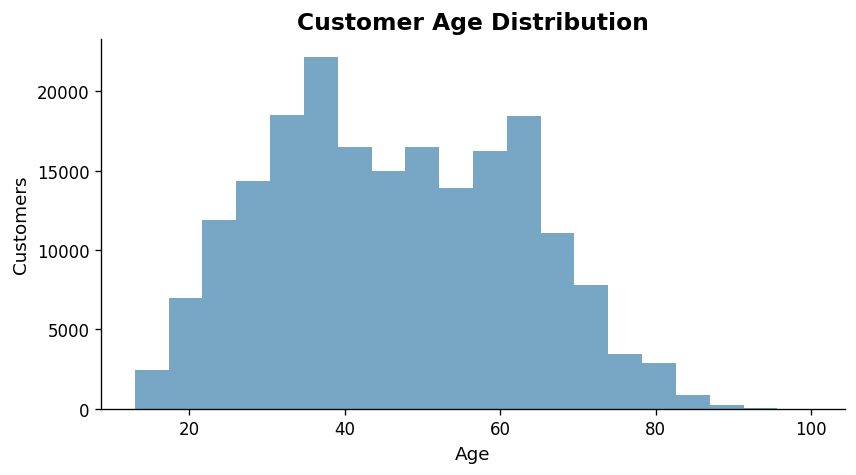

In [455]:
customer_age = duckdb_connection.execute(
    """
    SELECT age
    FROM clients
    WHERE age IS NOT NULL
    """
).df()

plt.figure(figsize=(8, 4))

plt.hist(
    customer_age["age"],
    bins=20,
    color=COLORS["serene_sea"],
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Customers")
plt.show()

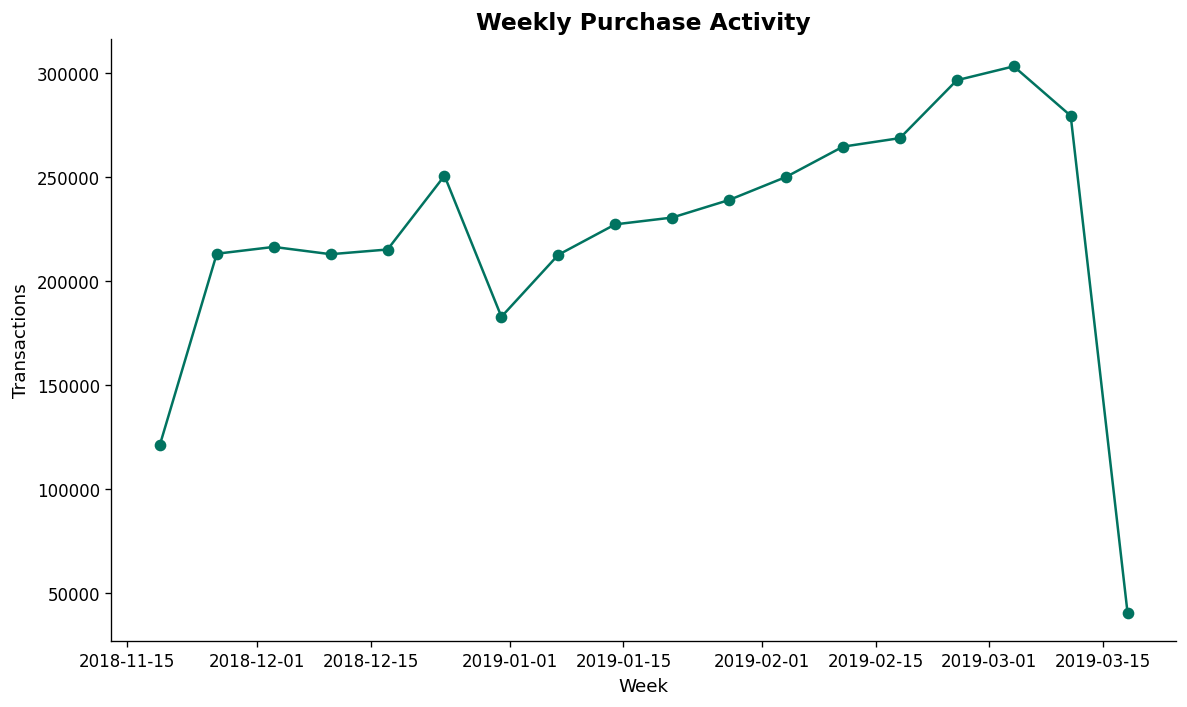

In [456]:
weekly_purchase_activity = duckdb_connection.execute(
    """
    SELECT
        DATE_TRUNC('week', transaction_datetime) AS week,
        COUNT(*) AS transactions
    FROM transactions
    GROUP BY week
    ORDER BY week
    """
).df()

plt.figure(figsize=(10, 6))

plt.plot(
    weekly_purchase_activity["week"],
    weekly_purchase_activity["transactions"],
    marker="o",
    color=COLORS["pacific_green"],
)

plt.title("Weekly Purchase Activity")
plt.xlabel("Week")
plt.ylabel("Transactions")
plt.tight_layout()
plt.show()

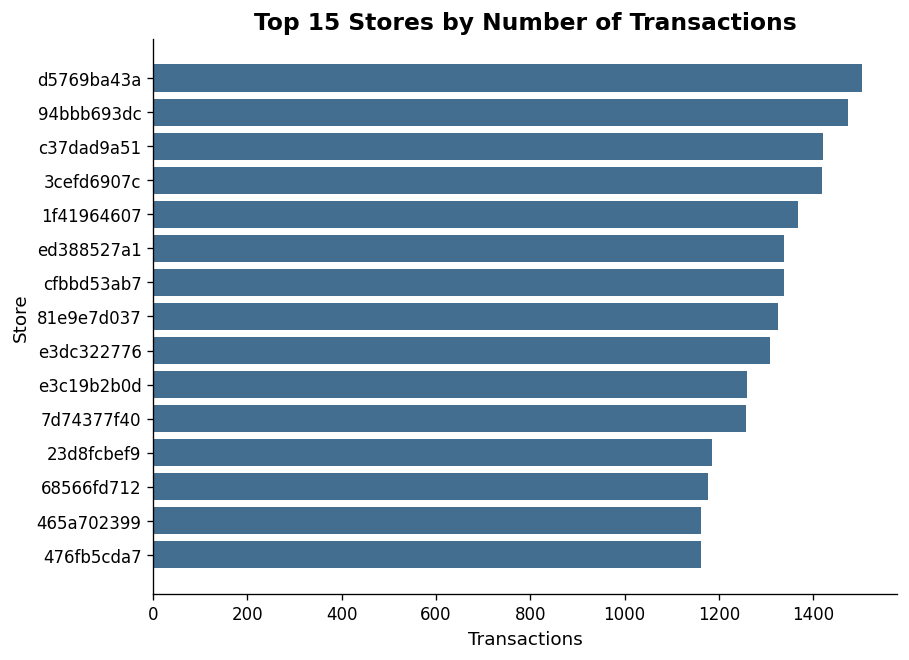

In [457]:
store_activity = duckdb_connection.execute(
    """
    SELECT
        store_id,
        COUNT(*) AS transactions
    FROM transactions
    GROUP BY store_id
    ORDER BY transactions DESC
    LIMIT 15
    """
).df()

store_activity = store_activity.sort_values(
    "transactions",
    ascending=True,
)

plt.figure(figsize=(8, 6))

plt.barh(
    store_activity["store_id"],
    store_activity["transactions"],
    color=COLORS["rainy_lake"],
)

plt.title("Top 15 Stores by Number of Transactions")
plt.xlabel("Transactions")
plt.ylabel("Store")
plt.show()

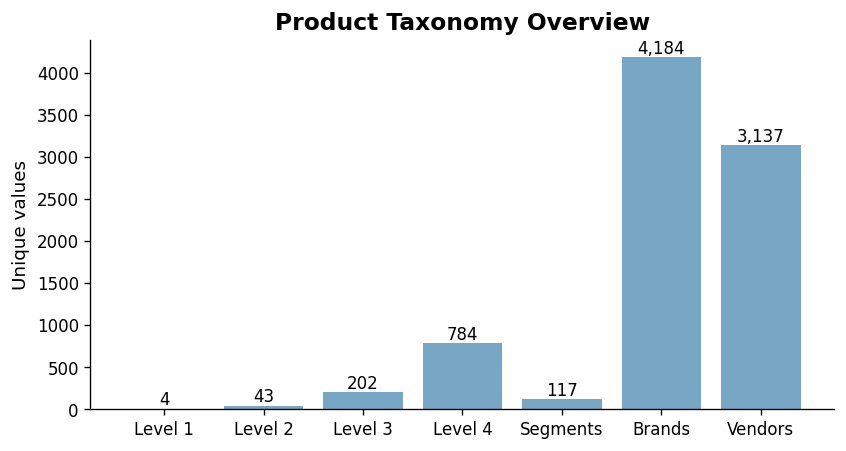

In [458]:
product_taxonomy = duckdb_connection.execute(
    """
    SELECT 'Level 1' AS category_level, COUNT(DISTINCT level_1) AS categories
    FROM products

    UNION ALL

    SELECT 'Level 2', COUNT(DISTINCT level_2)
    FROM products

    UNION ALL

    SELECT 'Level 3', COUNT(DISTINCT level_3)
    FROM products

    UNION ALL

    SELECT 'Level 4', COUNT(DISTINCT level_4)
    FROM products

    UNION ALL

    SELECT 'Segments', COUNT(DISTINCT segment_id)
    FROM products

    UNION ALL

    SELECT 'Brands', COUNT(DISTINCT brand_id)
    FROM products

    UNION ALL

    SELECT 'Vendors', COUNT(DISTINCT vendor_id)
    FROM products
    """
).df()

plt.figure(figsize=(8, 4))

bars = plt.bar(
    product_taxonomy["category_level"],
    product_taxonomy["categories"],
    color=COLORS["serene_sea"],
)

for bar, count in zip(
    bars,
    product_taxonomy["categories"],
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,.0f}",
        ha="center",
        va="bottom",
    )

plt.title("Product Taxonomy Overview")
plt.ylabel("Unique values")
plt.show()

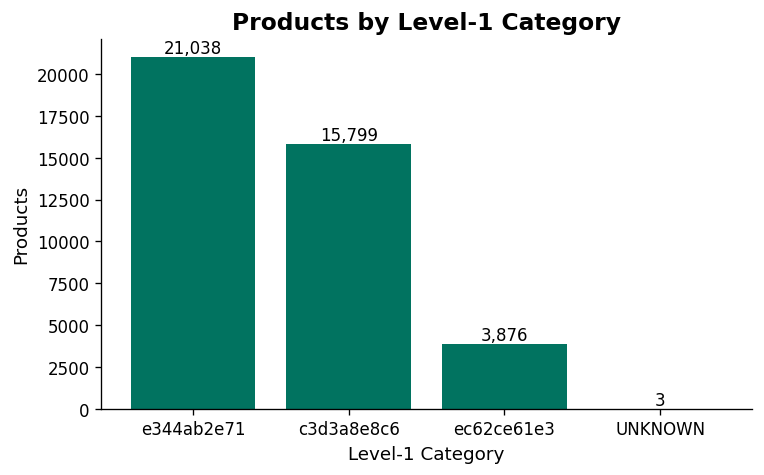

In [459]:
level_1_distribution = duckdb_connection.execute(
    """
    SELECT
        level_1,
        COUNT(*) AS products
    FROM products
    GROUP BY level_1
    ORDER BY products DESC
    """
).df()

plt.figure(figsize=(7, 4))

bars = plt.bar(
    level_1_distribution["level_1"],
    level_1_distribution["products"],
    color=COLORS["pacific_green"],
)

for bar, count in zip(
    bars,
    level_1_distribution["products"],
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,.0f}",
        ha="center",
        va="bottom",
    )

plt.title("Products by Level-1 Category")
plt.xlabel("Level-1 Category")
plt.ylabel("Products")
plt.show()

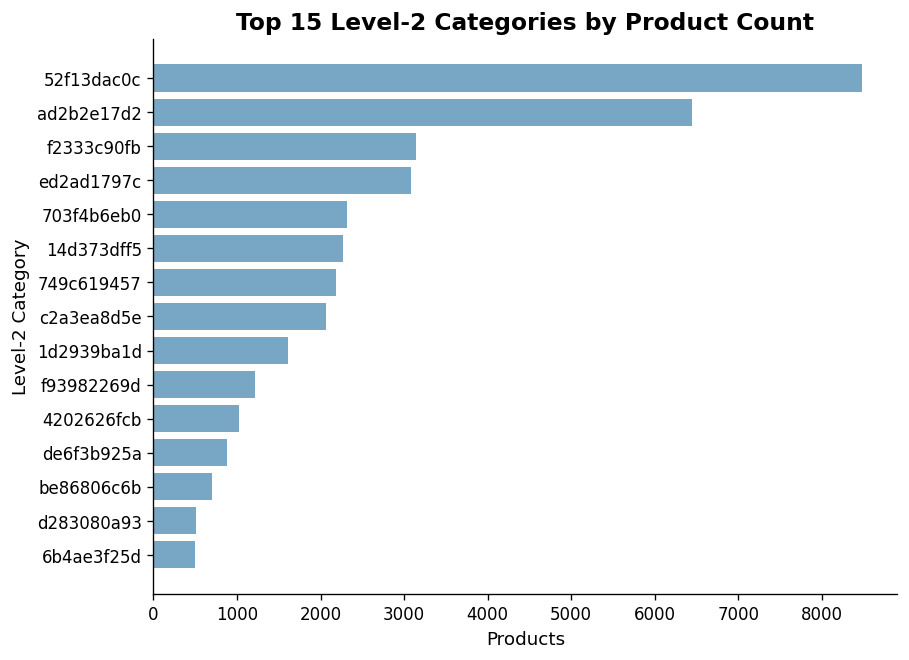

In [460]:
level_2_distribution = duckdb_connection.execute(
    """
    SELECT
        level_2,
        COUNT(*) AS products
    FROM products
    GROUP BY level_2
    ORDER BY products DESC
    LIMIT 15
    """
).df()

level_2_distribution = level_2_distribution.sort_values(
    "products",
    ascending=True,
)

plt.figure(figsize=(8, 6))

plt.barh(
    level_2_distribution["level_2"],
    level_2_distribution["products"],
    color=COLORS["serene_sea"],
)

plt.title("Top 15 Level-2 Categories by Product Count")
plt.xlabel("Products")
plt.ylabel("Level-2 Category")
plt.show()

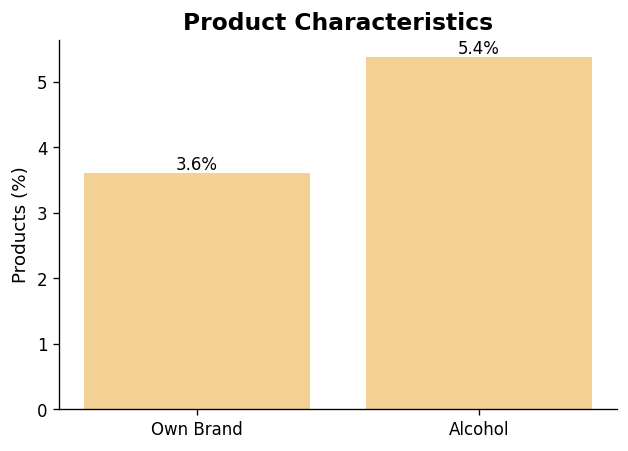

In [461]:
product_flags = duckdb_connection.execute(
    """
    SELECT
        100.0 * AVG(is_own_trademark) AS own_brand_percentage,
        100.0 * AVG(is_alcohol) AS alcohol_percentage
    FROM products
    """
).df()

product_flag_distribution = pd.DataFrame({
    "product_type": ["Own Brand", "Alcohol"],
    "percentage": [
        product_flags.loc[0, "own_brand_percentage"],
        product_flags.loc[0, "alcohol_percentage"],
    ],
})

plt.figure(figsize=(6, 4))

bars = plt.bar(
    product_flag_distribution["product_type"],
    product_flag_distribution["percentage"],
    color=COLORS["bungalow_maple"],
)

for bar, percentage in zip(
    bars,
    product_flag_distribution["percentage"],
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{percentage:.1f}%",
        ha="center",
        va="bottom",
    )

plt.title("Product Characteristics")
plt.ylabel("Products (%)")
plt.show()

### Broad EDA Findings

- Gender coverage is incomplete. Nearly half of customers are unknown (46.4%). Among known records, females (36.8%) significantly outnumber males (16.8%). While gender provides useful signal, the large missing segment must be handled carefully in modeling.

- Customers span a wide age range (25–70 years) with two main peaks around 30–40 and 55–65.

- Weekly purchases are steady, except for minor changes in late December and a rise in early March. The low counts in the first and last weeks are simply due to incomplete weeks.

- Purchases are well-distributed across stores. Even top-performing locations have similar sales volume, showing customers shop across a broad network rather than a few main stores.

- The product catalog is deep and hierarchical. It starts with 4 broad Level-1 groups (mostly concentrated in two) and expands down to 784 detailed Level-4 categories. Level-2 categories are uneven, dominated by a few large groups.

- The catalog features thousands of brands (4,184) and vendors (3,137). In contrast, own-brand items (3.6%) and alcohol products (5.4%) represent only small fractions of all products.

Overall, RetailHero covers a diverse mix of customers, stores, and products. Because shopping patterns vary widely across customer profiles, the next logical step is to aggregate the data down to customer-level behavior.

## Customer-Level Behavioral EDA

The campaign decision is made for each customer, so the transaction history is now summarized into one behavioral profile per customer.

The analysis follows six questions:

1. **Engagement** — How actively does the customer shop?
2. **Customer Value** — How much does the customer buy when they shop?
3. **Current Momentum** — Is that shopping activity still recent and active?
4. **Shopping Preference** — What kinds of products and categories do they buy?
5. **Shopping Footprint** — Where do they usually shop across the store network?
6. **Loyalty Behavior** — How strongly do they interact with the loyalty program?


In [462]:
RECENT_WINDOW_DAYS = 30

ANALYSIS_END_DATE = pd.Timestamp(ANALYSIS_END_TIMESTAMP).date()

RECENT_WINDOW_START_DATE = (ANALYSIS_END_DATE- pd.Timedelta(days=RECENT_WINDOW_DAYS - 1))

print("Analysis start:", ANALYSIS_START_TIMESTAMP)
print("Analysis end:", ANALYSIS_END_TIMESTAMP)
print("Recent window:",RECENT_WINDOW_START_DATE,"to",ANALYSIS_END_DATE,)

Analysis start: 2018-11-21 21:02:33
Analysis end: 2019-03-18 23:19:28
Recent window: 2019-02-17 to 2019-03-18


In [463]:
duckdb_connection.execute(
    f"""
    CREATE OR REPLACE VIEW customer_core_behavior AS

    WITH shopping_days AS (
        SELECT DISTINCT
            client_id,
            CAST(transaction_datetime AS DATE) AS shopping_date
        FROM transactions
    ),

    shopping_gaps AS (
        SELECT
            client_id,
            DATE_DIFF(
                'day',
                LAG(shopping_date) OVER (
                    PARTITION BY client_id
                    ORDER BY shopping_date
                ),
                shopping_date
            ) AS shopping_gap_days
        FROM shopping_days
    ),

    customer_gaps AS (
        SELECT
            client_id,
            AVG(shopping_gap_days) AS avg_shopping_gap_days
        FROM shopping_gaps
        WHERE shopping_gap_days IS NOT NULL
        GROUP BY client_id
    ),

    customer_transactions AS (
        SELECT
            client_id,

            DATE_DIFF(
                'day',
                CAST(MAX(transaction_datetime) AS DATE),
                DATE '{ANALYSIS_END_DATE.isoformat()}'
            ) AS recency_days,

            COUNT(*) AS transaction_count,

            COUNT(
                DISTINCT CAST(transaction_datetime AS DATE)
            ) AS active_days,

            SUM(purchase_sum) AS total_spend,

            AVG(purchase_sum) AS avg_transaction_value,
            MEDIAN(purchase_sum) AS median_transaction_value,

            AVG(basket_quantity) AS avg_basket_quantity,
            MEDIAN(basket_quantity) AS median_basket_quantity,

            COUNT(*) FILTER (
                WHERE transaction_datetime
                    >= DATE '{RECENT_WINDOW_START_DATE.isoformat()}'
            ) AS transactions_30d,

            COALESCE(
                SUM(purchase_sum) FILTER (
                    WHERE transaction_datetime
                        >= DATE '{RECENT_WINDOW_START_DATE.isoformat()}'
                ),
                0
            ) AS spend_30d,

            COUNT(
                DISTINCT CAST(transaction_datetime AS DATE)
            ) FILTER (
                WHERE transaction_datetime
                    >= DATE '{RECENT_WINDOW_START_DATE.isoformat()}'
            ) AS active_days_30d

        FROM transactions
        GROUP BY client_id
    )

    SELECT
        u.client_id,

        t.recency_days,
        t.transaction_count,
        t.active_days,

        t.total_spend,
        t.avg_transaction_value,
        t.median_transaction_value,
        t.avg_basket_quantity,
        t.median_basket_quantity,

        t.transactions_30d,
        t.spend_30d,
        t.active_days_30d,

        g.avg_shopping_gap_days,

        CASE
            WHEN g.avg_shopping_gap_days > 0
            THEN t.recency_days / g.avg_shopping_gap_days
            ELSE NULL
        END AS recency_gap_ratio

    FROM uplift_train AS u

    LEFT JOIN customer_transactions AS t
        USING (client_id)

    LEFT JOIN customer_gaps AS g
        USING (client_id)
    """
)

In [464]:
customer_core_behavior = duckdb_connection.execute(
    """
    SELECT *
    FROM customer_core_behavior
    ORDER BY client_id
    """
).df()

display(customer_core_behavior)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,client_id,recency_days,transaction_count,active_days,total_spend,avg_transaction_value,median_transaction_value,avg_basket_quantity,median_basket_quantity,transactions_30d,spend_30d,active_days_30d,avg_shopping_gap_days,recency_gap_ratio
0,000012768d,4,4,4,"2,803.0000",700.7500,688.5000,13.5000,13.5000,2,"1,222.0000",2,34.3333,0.1165
1,000036f903,1,32,32,"9,805.0000",306.4062,267.0000,5.2812,4.5000,9,"2,968.0000",9,3.5161,0.2844
2,00010925a5,10,18,17,"5,883.0000",326.8333,301.0000,4.3889,4.5000,8,"2,858.0000",7,6.4375,1.5534
3,0001f552b0,2,15,13,"6,155.1800",410.3453,335.3700,7.0667,5.0000,7,"2,211.3700",6,9.3333,0.2143
4,00020e7b18,3,18,16,"25,819.6100","1,434.4228","1,222.6750",21.8889,20.0000,5,"6,096.2700",4,7.4667,0.4018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200034,fffe0abb97,3,9,8,"2,716.4200",301.8244,159.9700,4.4444,2.0000,3,820.7200,3,15.0000,0.2000
200035,fffe0ed719,0,30,28,"10,417.4800",347.2493,309.0000,7.2333,7.0000,19,"8,551.4800",19,4.2963,0.0000
200036,fffea1204c,5,17,17,"4,297.1200",252.7718,183.0000,6.5294,5.0000,6,"1,746.4100",6,6.3125,0.7921
200037,fffeca6d22,3,16,13,"2,832.8600",177.0538,130.4300,4.1250,3.0000,9,"1,251.8600",6,8.4167,0.3564


In [465]:
customer_grain_check = pd.DataFrame({
    "rows": [len(customer_core_behavior)],
    "unique_customers": [customer_core_behavior["client_id"].nunique()],
})

display(
    style_table(
        customer_grain_check,
        formats={
            "rows": "{:,.0f}",
            "unique_customers": "{:,.0f}",
        },
    )
)

rows,unique_customers
"200,039","200,039"


#### How attached is the customer to the retailer?

- **Recency** — days since the customer's latest purchase
- **Transaction count** — how many shopping transactions they made
- **Active days** — how many different days they visited and purchased

Together, these show the difference between frequent, recent shoppers and customers with lighter shopping activity.

In [466]:
PLOT_UPPER_QUANTILE = 0.99


def summarize_metrics(
    data: pd.DataFrame,
    columns: list[str],
) -> pd.DataFrame:
    """Summarize selected numeric metrics with robust percentiles."""

    summary = (
        data[columns]
        .quantile([0.25, 0.50, 0.75, 0.95])
        .T
        .rename(
            columns={
                0.25: "p25",
                0.50: "median",
                0.75: "p75",
                0.95: "p95",
            }
        )
        .reset_index()
        .rename(columns={"index": "metric"})
    )

    return summary

In [467]:
engagement_summary = summarize_metrics(
    customer_core_behavior,
    [
        "recency_days",
        "transaction_count",
        "active_days",
    ],
)

display(
    style_table(
        engagement_summary,
        formats={
            "p25": "{:,.1f}",
            "median": "{:,.1f}",
            "p75": "{:,.1f}",
            "p95": "{:,.1f}",
        },
    )
)

metric,p25,median,p75,p95
recency_days,1.0,4.0,9.0,18.0
transaction_count,8.0,15.0,27.0,54.0
active_days,8.0,14.0,24.0,46.0


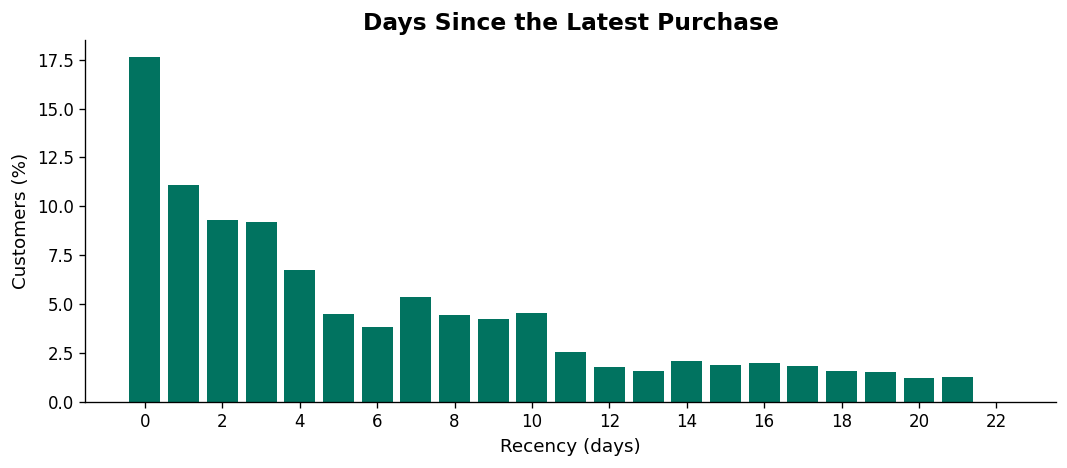

In [468]:
recency_distribution = (
    customer_core_behavior["recency_days"]
    .value_counts()
    .sort_index()
    .rename_axis("recency_days")
    .reset_index(name="customers")
)

recency_distribution["percentage"] = (
    100 * recency_distribution["customers"] / recency_distribution["customers"].sum()
)

plt.figure(figsize=(9, 4))

plt.bar(
    recency_distribution["recency_days"],
    recency_distribution["percentage"],
    color=COLORS["pacific_green"],
)

max_recency = int(recency_distribution["recency_days"].max())

plt.xticks(range(0, max_recency + 1, 2))

plt.title("Days Since the Latest Purchase")
plt.xlabel("Recency (days)")
plt.ylabel("Customers (%)")
plt.tight_layout()
plt.show()

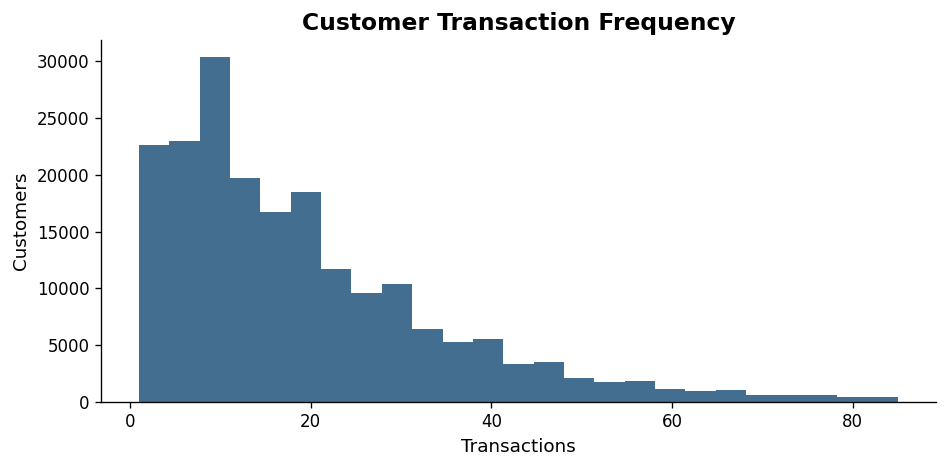

In [469]:
transaction_count_upper = customer_core_behavior["transaction_count"].quantile(PLOT_UPPER_QUANTILE)

plt.figure(figsize=(8, 4))

plt.hist(
    customer_core_behavior.loc[
        customer_core_behavior["transaction_count"] <= transaction_count_upper,
        "transaction_count",
    ],
    bins=25,
    color=COLORS["rainy_lake"],
)

plt.title("Customer Transaction Frequency")
plt.xlabel("Transactions")
plt.ylabel("Customers")
plt.tight_layout()
plt.show()

- Shopping frequency varies significantly across the customer base. While the median customer makes 15 transactions, the middle 50% rannges from 8-27 purchases. Notably the top 5% of highly engaged customer complete over 50 transcations.

- Typically, one visit equals one transaction. The median number of active `shopping days(14 days)` closely matches the `median transaction count (15 transactions)`. This indicates that customers rarely split their purchases into multiple orders on the same day.

- Customer engagement remains strong up to the end of the analysis window (March 18, 2019). The median recency is just 4 days, and 75% of customers have made a purchase within the last 9 days. There is also a distinct spike at day 0, highlighting a large volume of transactions occurring on the very last recorded day.

#### Shopping frequently does not always mean spending heavily.

The next question is how much customers buy when they shop:

- **Total spend** — the total value purchased during the history
- **Transaction value** — how much they typically spend per transaction
- **Basket size** — how many items they usually buy in one transaction

These measures separate frequent small-basket shoppers from customers who make larger purchases.

In [470]:
customer_value_summary = summarize_metrics(
    customer_core_behavior,
    [
        "total_spend",
        "avg_transaction_value",
        "median_transaction_value",
        "avg_basket_quantity",
        "median_basket_quantity",
    ],
)

display(
    style_table(
        customer_value_summary,
        formats={
            "p25": "{:,.2f}",
            "median": "{:,.2f}",
            "p75": "{:,.2f}",
            "p95": "{:,.2f}",
        },
    )
)

metric,p25,median,p75,p95
total_spend,"3,147.61","6,102.44","11,094.18","24,235.25"
avg_transaction_value,261.29,394.00,608.74,"1,193.48"
median_transaction_value,209.00,330.95,533.50,"1,101.98"
avg_basket_quantity,4.54,6.64,9.83,18.00
median_basket_quantity,4.00,6.00,9.00,17.00


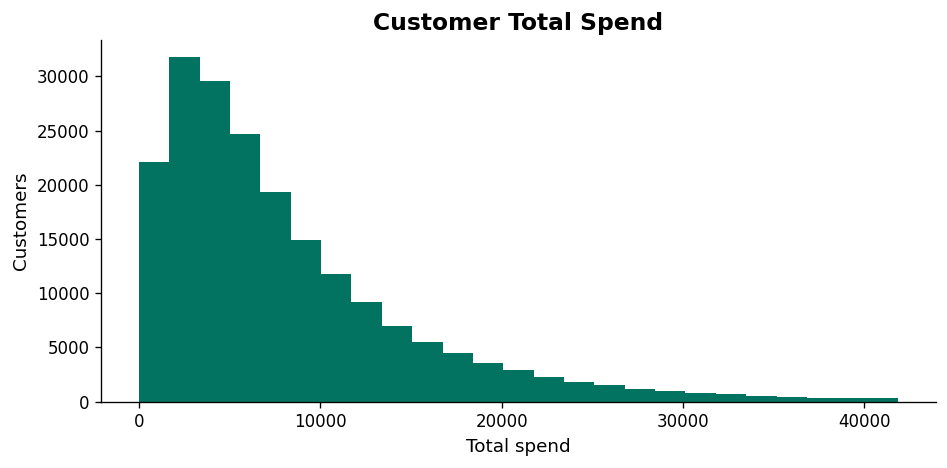

In [471]:
total_spend_upper = customer_core_behavior["total_spend"].quantile(PLOT_UPPER_QUANTILE)

plt.figure(figsize=(8, 4))

plt.hist(
    customer_core_behavior.loc[
        customer_core_behavior["total_spend"] <= total_spend_upper,
        "total_spend",
    ],
    bins=25,
    color=COLORS["pacific_green"],
)

plt.title("Customer Total Spend")
plt.xlabel("Total spend")
plt.ylabel("Customers")
plt.tight_layout()
plt.show()

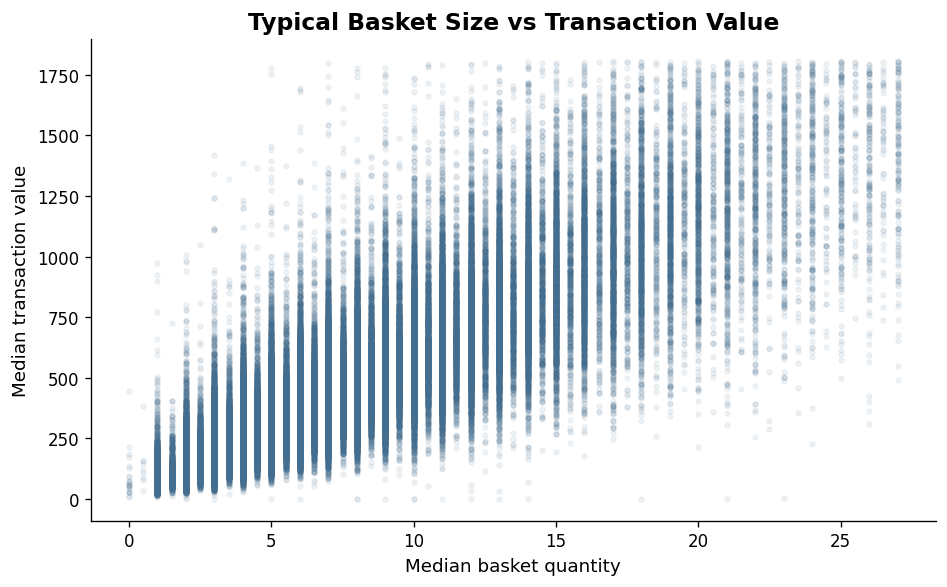

In [472]:
basket_upper = customer_core_behavior["median_basket_quantity"].quantile(PLOT_UPPER_QUANTILE)

transaction_value_upper = customer_core_behavior["median_transaction_value"].quantile(PLOT_UPPER_QUANTILE)

customer_value_relationship = customer_core_behavior.loc[
    (
        customer_core_behavior["median_basket_quantity"] <= basket_upper
    )
    & (
        customer_core_behavior["median_transaction_value"] <= transaction_value_upper
    )
]

plt.figure(figsize=(8, 5))

plt.scatter(
    customer_value_relationship["median_basket_quantity"],
    customer_value_relationship["median_transaction_value"],
    s=8,
    alpha=0.08,
    color=COLORS["rainy_lake"],
)

plt.title("Typical Basket Size vs Transaction Value")
plt.xlabel("Median basket quantity")
plt.ylabel("Median transaction value")
plt.tight_layout()
plt.show()

- Total customer spend is highly right-skewed. While the majority of customers spend around the median of 6,102, the top 5% of VIP customers spend upwards of 24,235.

- Top customers don't reach their high total spend via a few massive purchases. The data shows a median transaction is only 331, yet top lifetime spends reach tens of thousands. This massive gap proves that high customer value is built through repeated, consistent visits over time.

- While buying more items generally increases the bill, the scatter plot reveals a wide variance: two customers buying the exact same number of items can have vastly different checkout totals. This difference is driven by the price points of the specific products they choose.

A customer's economic value to RetailHero is ultimately determined by two core factors: how often they return to shop and the price tier of the items in their typical basket.

### Current Momentum

Strong historical activity does not always mean that a customer is still active now.

Two customers may have similar purchase history but very different recent behavior.

The `latest 30-day window`(2019-02-17 to 2019-03-18) is therefore used to examine:

- How many transactions the customer made recently
- How much they spent recently
- How many days they were active recently
- How many days usually pass between shopping visits

These measures show whether the customer's shopping activity is still active or has started to slow down.

In [473]:
momentum_summary = summarize_metrics(
    customer_core_behavior,
    [
        "transactions_30d",
        "spend_30d",
        "active_days_30d",
        "avg_shopping_gap_days",
        "recency_gap_ratio",
    ],
)

display(
    style_table(
        momentum_summary,
        formats={
            "p25": "{:,.2f}",
            "median": "{:,.2f}",
            "p75": "{:,.2f}",
            "p95": "{:,.2f}",
        },
    )
)

metric,p25,median,p75,p95
transactions_30d,2.00,4.00,8.00,17.00
spend_30d,854.35,"1,791.00","3,393.37","7,812.01"
active_days_30d,2.00,4.00,7.00,14.00
avg_shopping_gap_days,4.15,6.76,11.67,28.33
recency_gap_ratio,0.16,0.47,1.00,2.48


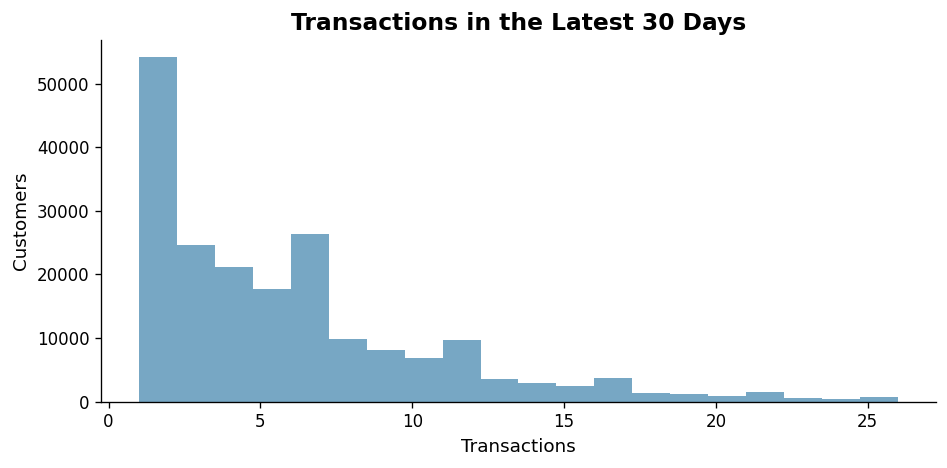

In [474]:
recent_transactions_upper = customer_core_behavior["transactions_30d"].quantile(PLOT_UPPER_QUANTILE)

plt.figure(figsize=(8, 4))

plt.hist(
    customer_core_behavior.loc[
        customer_core_behavior["transactions_30d"] <= recent_transactions_upper,
        "transactions_30d",
    ],
    bins=20,
    color=COLORS["serene_sea"],
)

plt.title("Transactions in the Latest 30 Days")
plt.xlabel("Transactions")
plt.ylabel("Customers")
plt.tight_layout()
plt.show()

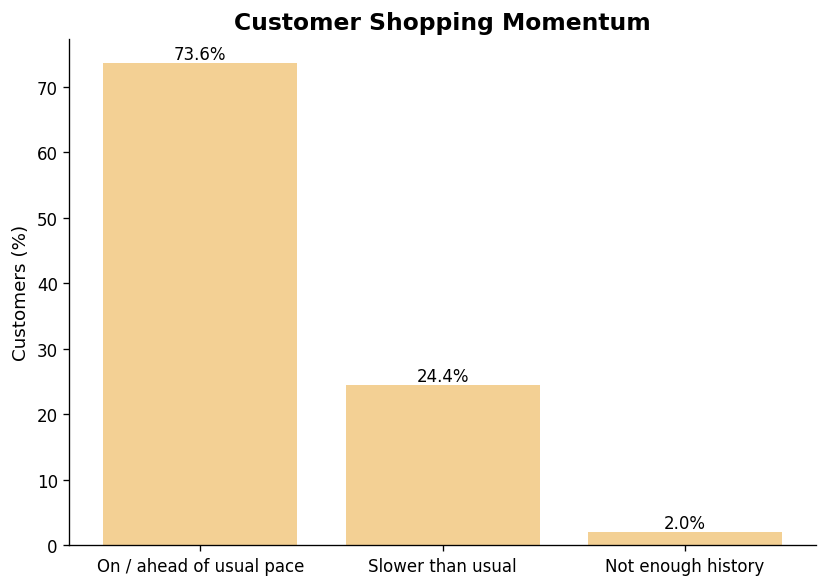

In [475]:
momentum_status = pd.Series("Not enough history",index=customer_core_behavior.index,)

has_shopping_gap = customer_core_behavior["avg_shopping_gap_days"].notna()

momentum_status.loc[has_shopping_gap & (customer_core_behavior["recency_gap_ratio"] <= 1)] = "On / ahead of usual pace"

momentum_status.loc[has_shopping_gap& (customer_core_behavior["recency_gap_ratio"] > 1)] = "Slower than usual"

momentum_distribution = (
    momentum_status
    .value_counts()
    .reindex(
        [
            "On / ahead of usual pace",
            "Slower than usual",
            "Not enough history",
        ],
        fill_value=0,
    )
    .rename_axis("momentum")
    .reset_index(name="customers")
)

momentum_distribution["percentage"] = (
    100
    * momentum_distribution["customers"]
    / momentum_distribution["customers"].sum()
)

plt.figure(figsize=(7, 5))

bars = plt.bar(
    momentum_distribution["momentum"],
    momentum_distribution["percentage"],
    color=COLORS["bungalow_maple"],
)

for bar, percentage in zip(
    bars,
    momentum_distribution["percentage"],
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{percentage:.1f}%",
        ha="center",
        va="bottom",
    )

plt.title("Customer Shopping Momentum")
plt.ylabel("Customers (%)")
plt.tight_layout()
plt.show()

- Most customers make about 4 purchases a month, but the top 25% check out 8+ times. The 30-day spend reflects this gap: the median is 1,791, while the top group spends well over 3,393.

- On average, customers return every 6-7 days. To accurately spot if someone is losing interest, we compare their current absence to their own normal rhythm. (e.g., If a customer normally shops every 4 days but hasn't bought anything in 12 days -> Red flag).

- 73.6% of the customer base is on track, maintaining their normal shopping pace. However, 24.4% are clearly slowing down compared to their usual habits. This specific group requires immediate re-engagement before they churn completely.

In general, the customer base still has strong shopping momentum before the campaign. However, about a quarter of customers showed signs of slowing down from their own usual behavior.


### Customer Activity & Value

- Overall, the customer base is still well-connected to the store. However, shopping habits vary wildly: some visit constantly with small baskets, while others are rare visitors who spend big.

- We cannot simply label customers as just "active" or "inactive". The reality is much more nuanced. Customers differ significantly across three key dimensions: Engagement, Shopping Value, and Current Momentum (keeping in mind the 25% who are currently slowing down).

- These pre-existing behavioral differences are crucial. They set the baseline for our next step: analyzing whether these different customer profiles will react differently to the upcoming promotional campaign.

### Shopping Preference

This section therefore looks at:

- **Product breadth**: how many different products, categories, brands, vendors, and segments the customer explores
- **Repeat preference**: how strongly the customer returns to the same favorite product
- **Special product preference**: how often their transactions include own-brand or alcohol products

Together, these describe whether the customer's shopping style is broad and exploratory or more focused and repetitive.

In [476]:
duckdb_connection.execute(
    """
    CREATE OR REPLACE VIEW customer_product_behavior AS

    WITH purchase_products AS (
        SELECT
            p.client_id,
            p.transaction_id,
            p.transaction_datetime,
            p.store_id,
            p.product_id,

            pr.level_1,
            pr.level_2,
            pr.level_3,
            pr.level_4,
            pr.segment_id,
            pr.brand_id,
            pr.vendor_id,
            pr.is_own_trademark,
            pr.is_alcohol

        FROM purchases AS p

        INNER JOIN products AS pr
            USING (product_id)
    ),

    customer_product_breadth AS (
        SELECT
            client_id,

            COUNT(DISTINCT product_id) AS unique_products,

            COUNT(DISTINCT level_1) AS unique_level_1_categories,
            COUNT(DISTINCT level_2) AS unique_level_2_categories,
            COUNT(DISTINCT level_3) AS unique_level_3_categories,
            COUNT(DISTINCT level_4) AS unique_level_4_categories,

            COUNT(DISTINCT segment_id) AS unique_segments,
            COUNT(DISTINCT brand_id) AS unique_brands,
            COUNT(DISTINCT vendor_id) AS unique_vendors

        FROM purchase_products
        GROUP BY client_id
    ),

    product_transaction_presence AS (
        SELECT DISTINCT
            client_id,
            transaction_id,
            transaction_datetime,
            store_id,
            product_id

        FROM purchase_products
    ),

    customer_product_repeat AS (
        SELECT
            client_id,
            product_id,
            COUNT(*) AS transactions_with_product

        FROM product_transaction_presence

        GROUP BY
            client_id,
            product_id
    ),

    favorite_product AS (
        SELECT
            client_id,
            MAX(transactions_with_product) AS favorite_product_transactions

        FROM customer_product_repeat
        GROUP BY client_id
    ),

    transaction_product_flags AS (
        SELECT
            client_id,
            transaction_id,
            transaction_datetime,
            store_id,

            MAX(CAST(is_own_trademark AS INTEGER)) AS has_own_brand,

            MAX(CAST(is_alcohol AS INTEGER)) AS has_alcohol

        FROM purchase_products

        GROUP BY
            client_id,
            transaction_id,
            transaction_datetime,
            store_id
    ),

    customer_product_flags AS (
        SELECT
            client_id,

            AVG(has_own_brand) AS own_brand_transaction_share,

            AVG(has_alcohol) AS alcohol_transaction_share

        FROM transaction_product_flags
        GROUP BY client_id
    )

    SELECT
        u.client_id,

        b.unique_products,

        b.unique_level_1_categories,
        b.unique_level_2_categories,
        b.unique_level_3_categories,
        b.unique_level_4_categories,

        b.unique_segments,
        b.unique_brands,
        b.unique_vendors,

        f.favorite_product_transactions,

        1.0 * f.favorite_product_transactions / c.transaction_count AS favorite_product_share,

        p.own_brand_transaction_share,
        p.alcohol_transaction_share

    FROM uplift_train AS u

    LEFT JOIN customer_product_breadth AS b
        USING (client_id)

    LEFT JOIN favorite_product AS f
        USING (client_id)

    LEFT JOIN customer_product_flags AS p
        USING (client_id)

    LEFT JOIN customer_core_behavior AS c
        USING (client_id)
    """
)

In [477]:
customer_product_behavior = duckdb_connection.execute(
    """
    SELECT *
    FROM customer_product_behavior
    ORDER BY client_id
    """
).df()

display(customer_product_behavior)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,client_id,unique_products,unique_level_1_categories,unique_level_2_categories,unique_level_3_categories,unique_level_4_categories,unique_segments,unique_brands,unique_vendors,favorite_product_transactions,favorite_product_share,own_brand_transaction_share,alcohol_transaction_share
0,000012768d,46,3,8,24,31,24,29,29,2,0.5000,0.7500,0.0000
1,000036f903,96,3,12,39,58,42,52,44,8,0.2500,0.3750,0.0312
2,00010925a5,58,3,10,24,47,32,28,24,5,0.2778,0.3889,0.0556
3,0001f552b0,79,3,13,39,57,41,47,42,3,0.2000,0.4667,0.0000
4,00020e7b18,175,3,13,48,74,45,87,69,14,0.7778,0.8333,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
200034,fffe0abb97,36,3,12,24,28,25,27,24,2,0.2222,0.1111,0.0000
200035,fffe0ed719,89,3,9,33,50,37,53,52,14,0.4667,0.7333,0.0000
200036,fffea1204c,45,3,10,16,25,18,25,23,7,0.4118,0.0000,0.0000
200037,fffeca6d22,34,3,10,20,25,22,20,19,10,0.6250,0.0625,0.0000


In [478]:
product_breadth_summary = summarize_metrics(
    customer_product_behavior,
    [
        "unique_products",
        "unique_level_1_categories",
        "unique_level_2_categories",
        "unique_level_3_categories",
        "unique_level_4_categories",
        "unique_segments",
        "unique_brands",
        "unique_vendors",
    ],
)

display(
    style_table(
        product_breadth_summary,
        formats={
            "p25": "{:,.1f}",
            "median": "{:,.1f}",
            "p75": "{:,.1f}",
            "p95": "{:,.1f}",
        },
    )
)

metric,p25,median,p75,p95
unique_products,35.0,62.0,101.0,183.0
unique_level_1_categories,2.0,3.0,3.0,3.0
unique_level_2_categories,9.0,12.0,15.0,20.0
unique_level_3_categories,21.0,31.0,42.0,60.0
unique_level_4_categories,26.0,42.0,62.0,97.0
unique_segments,22.0,33.0,44.0,61.0
unique_brands,23.0,39.0,60.0,101.0
unique_vendors,21.0,33.0,50.0,82.0


In [479]:
repeat_preference_summary = summarize_metrics(
    customer_product_behavior,
    [
        "favorite_product_transactions",
        "favorite_product_share",
        "own_brand_transaction_share",
        "alcohol_transaction_share",
    ],
)

share_metrics = [
    "favorite_product_share",
    "own_brand_transaction_share",
    "alcohol_transaction_share",
]

share_rows = repeat_preference_summary["metric"].isin(share_metrics)

summary_columns = [
    "p25",
    "median",
    "p75",
    "p95",
]

repeat_preference_summary.loc[share_rows,summary_columns,] *= 100

repeat_preference_summary.loc[share_rows,"metric",] += " (%)"

display(
    style_table(
        repeat_preference_summary,
        formats={
            "p25": "{:,.1f}",
            "median": "{:,.1f}",
            "p75": "{:,.1f}",
            "p95": "{:,.1f}",
        },
    )
)

metric,p25,median,p75,p95
favorite_product_transactions,3.0,6.0,11.0,23.0
favorite_product_share (%),28.6,42.1,61.9,100.0
own_brand_transaction_share (%),33.3,53.8,75.0,100.0
alcohol_transaction_share (%),0.0,0.0,10.0,45.5


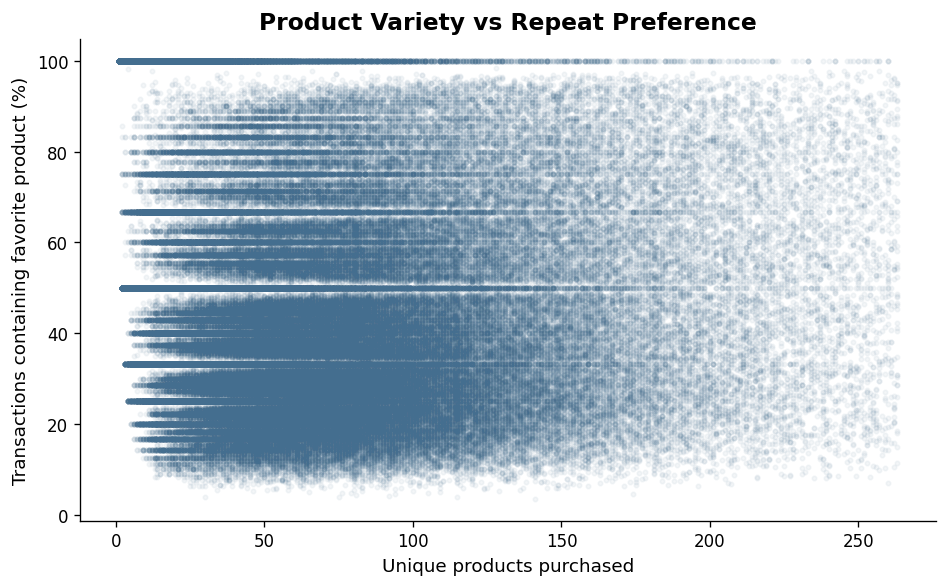

In [480]:
product_variety_upper = customer_product_behavior["unique_products"].quantile(PLOT_UPPER_QUANTILE)

product_preference_plot = customer_product_behavior.loc[customer_product_behavior["unique_products"] <= product_variety_upper]

plt.figure(figsize=(8, 5))

plt.scatter(
    product_preference_plot["unique_products"],
    100 * product_preference_plot["favorite_product_share"],
    s=7,
    alpha=0.06,
    color=COLORS["rainy_lake"],
)

plt.title("Product Variety vs Repeat Preference")
plt.xlabel("Unique products purchased")
plt.ylabel("Transactions containing favorite product (%)")
plt.tight_layout()
plt.show()

In [481]:
special_product_behavior = pd.DataFrame({
    "product_type": [
        "Own-brand",
        "Alcohol",
    ],
    "customers_ever_bought_pct": [
        100 * (customer_product_behavior["own_brand_transaction_share"] > 0).mean(),
        100 * (customer_product_behavior["alcohol_transaction_share"] > 0).mean(),
    ],
    "avg_transaction_share_pct": [
        100 * customer_product_behavior["own_brand_transaction_share"].mean(),
        100 * customer_product_behavior["alcohol_transaction_share"].mean(),
    ],
})

display(
    style_table(
        special_product_behavior,
        formats={
            "customers_ever_bought_pct": "{:.1f}%",
            "avg_transaction_share_pct": "{:.1f}%",
        },
    )
)

product_type,customers_ever_bought_pct,avg_transaction_share_pct
Own-brand,96.9%,54.0%
Alcohol,42.9%,8.6%


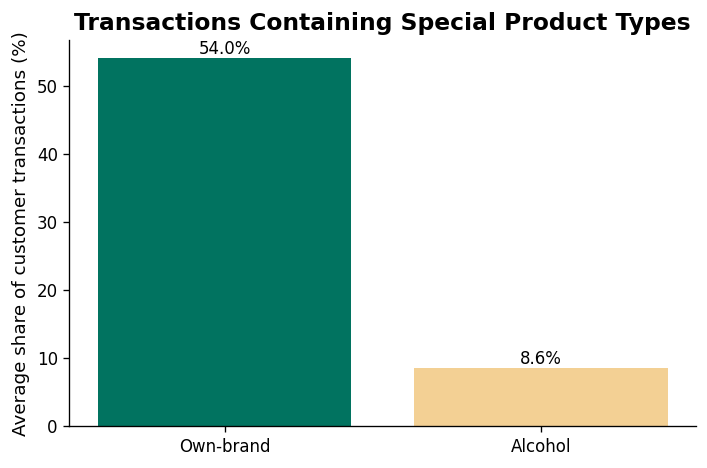

In [482]:
plt.figure(figsize=(6, 4))

bars = plt.bar(
    special_product_behavior["product_type"],
    special_product_behavior["avg_transaction_share_pct"],
    color=[
        COLORS["pacific_green"],
        COLORS["bungalow_maple"],
    ],
)

for bar, percentage in zip(
    bars,
    special_product_behavior["avg_transaction_share_pct"],
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{percentage:.1f}%",
        ha="center",
        va="bottom",
    )

plt.title("Transactions Containing Special Product Types")
plt.ylabel("Average share of customer transactions (%)")
plt.tight_layout()
plt.show()

- Shopping baskets are diverse, with a typical customer purchasing 62 different products. However, the `Product Variety vs Repeat Preference chart` indicates that buying a wide variety of items does not eliminate repeat purchases. 

- Even customers who buy hundreds of different products still regularly return to specific items. For an average customer, their single most frequently bought product appears in 42% of their transactions.

- When looking at specific product categories, the shopping patterns differ significantly:

    * `Own-brand`: These products are universally accepted, with 96.9% of customers having purchased them. They appear in 54% of an average customer's transactions, indicating they are deeply embedded in regular shopping routines.

    * `Alcohol`: In contrast, alcohol is a much more selective purchase. Only 42.9% of customers have ever bought it, and it appears in just 8.6% of total transactions.

Customers display a clear mix of product variety and consistent routine. While they explore many different items, they maintain a high repeat rate for familiar products.

### Shopping Footprint

RetailHero provides store identifiers but no physical location information, so this analysis cannot measure geographic distance or actual travel behavior.


- **Store breadth**: how many different stores the customer uses
- **Store concentration**: how much of their shopping happens at their most-used store
- **Single-store vs multi-store behavior**: whether the customer stays with one familiar store or shops across several locations


In [483]:
duckdb_connection.execute(
    """
    CREATE OR REPLACE VIEW customer_store_behavior AS

    WITH customer_store_transactions AS (
        SELECT
            client_id,
            store_id,
            COUNT(*) AS store_transactions

        FROM transactions

        GROUP BY
            client_id,
            store_id
    ),

    customer_store_summary AS (
        SELECT
            client_id,

            COUNT(*) AS unique_stores,

            MAX(store_transactions) AS favorite_store_transactions

        FROM customer_store_transactions

        GROUP BY client_id
    )

    SELECT
        u.client_id,

        s.unique_stores,
        s.favorite_store_transactions,

        1.0 * s.favorite_store_transactions / c.transaction_count AS favorite_store_share

    FROM uplift_train AS u

    LEFT JOIN customer_store_summary AS s
        USING (client_id)

    LEFT JOIN customer_core_behavior AS c
        USING (client_id)
    """
)

In [484]:
customer_store_behavior = duckdb_connection.execute(
    """
    SELECT *
    FROM customer_store_behavior
    ORDER BY client_id
    """
).df()

display(customer_store_behavior.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,client_id,unique_stores,favorite_store_transactions,favorite_store_share
0,000012768d,3,2,0.5000
1,000036f903,5,25,0.7812
2,00010925a5,2,11,0.6111
3,0001f552b0,4,10,0.6667
4,00020e7b18,4,12,0.6667


In [485]:
store_behavior_summary = summarize_metrics(
    customer_store_behavior,
    [
        "unique_stores",
        "favorite_store_transactions",
        "favorite_store_share",
    ],
)

favorite_store_row = (store_behavior_summary["metric"] == "favorite_store_share")

store_behavior_summary.loc[
    favorite_store_row,
    [
        "p25",
        "median",
        "p75",
        "p95",
    ],
] *= 100

store_behavior_summary.loc[favorite_store_row,"metric",] = "favorite_store_share (%)"

display(
    style_table(
        store_behavior_summary,
        formats={
            "p25": "{:,.1f}",
            "median": "{:,.1f}",
            "p75": "{:,.1f}",
            "p95": "{:,.1f}",
        },
    )
)

metric,p25,median,p75,p95
unique_stores,2.0,2.0,4.0,7.0
favorite_store_transactions,5.0,11.0,20.0,44.0
favorite_store_share (%),57.1,79.2,99.0,100.0


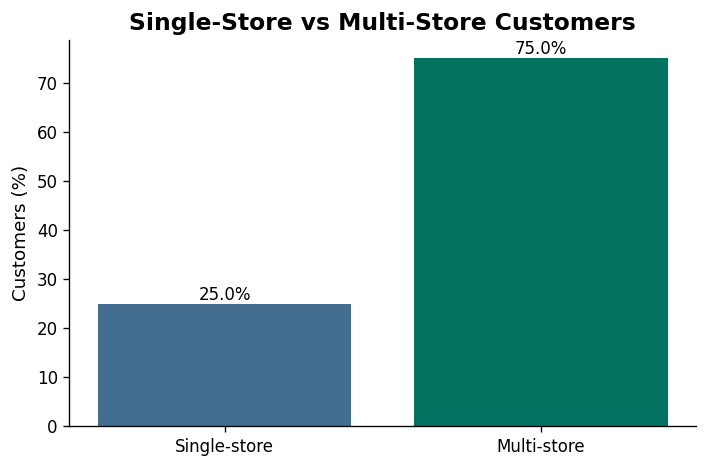

In [486]:
store_breadth_distribution = pd.DataFrame({
    "shopping_pattern": [
        "Single-store",
        "Multi-store",
    ],
    "customers": [
        (customer_store_behavior["unique_stores"] == 1).sum(),
        (customer_store_behavior["unique_stores"] > 1).sum(),
    ],
})

store_breadth_distribution["percentage"] = (
    100 * store_breadth_distribution["customers"] / store_breadth_distribution["customers"].sum()
)

plt.figure(figsize=(6, 4))

bars = plt.bar(
    store_breadth_distribution["shopping_pattern"],
    store_breadth_distribution["percentage"],
    color=[
        COLORS["rainy_lake"],
        COLORS["pacific_green"],
    ],
)

for bar, percentage in zip(
    bars,
    store_breadth_distribution["percentage"],
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{percentage:.1f}%",
        ha="center",
        va="bottom",
    )

plt.title("Single-Store vs Multi-Store Customers")
plt.ylabel("Customers (%)")
plt.tight_layout()
plt.show()

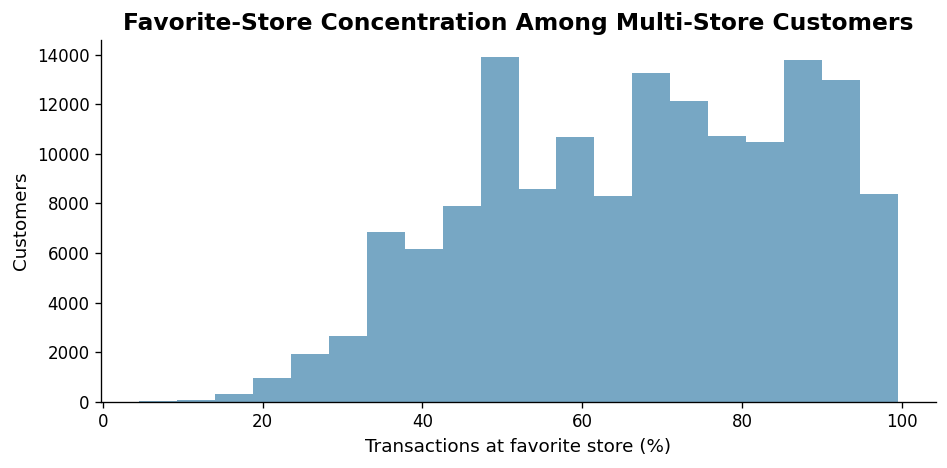

In [487]:
multi_store_customers = customer_store_behavior.loc[
    customer_store_behavior["unique_stores"] > 1,
    "favorite_store_share",
]

plt.figure(figsize=(8, 4))

plt.hist(
    100 * multi_store_customers,
    bins=20,
    color=COLORS["serene_sea"],
)

plt.title("Favorite-Store Concentration Among Multi-Store Customers")
plt.xlabel("Transactions at favorite store (%)")
plt.ylabel("Customers")
plt.tight_layout()
plt.show()

- Customers do not limit themselves to a single location. The data shows that 75% of shoppers visit multiple stores across the RetailHero network.

- Even though they visit different branches, shoppers do not split their spending evenly. A typical customer still makes about 79% of all their purchases at one favorite store, treating the other locations merely as secondary options.

Customers display both store flexibility and store loyalty. They visit multiple RetailHero locations, but they still conduct the vast majority of their transactions at a single primary store.

### Loyalty Behavior

Receiving points and redeeming them represent two different parts of this relationship. A customer may collect points frequently but rarely use them, while another customer may actively return and redeem rewards.

- **Point earning**: how often and how many regular and express points customers receive
- **Point redemption**: how often customers actually use their accumulated points
- **Recent loyalty activity**: whether point redemption is still happening close to the campaign
- **Redemption context**: whether customers tend to redeem points on larger or smaller shopping trips
- **Redemption timing**: how recently and how regularly customers use their points

Regular and express points are kept separate because they are recorded as different fields in the source data.

In [488]:
duckdb_connection.execute(
    f"""
    CREATE OR REPLACE VIEW customer_loyalty_behavior AS

    WITH transaction_loyalty AS (
        SELECT
            client_id,
            transaction_id,
            transaction_datetime,
            store_id,
            purchase_sum,
            basket_quantity,

            regular_points_received,
            express_points_received,

            -regular_points_spent AS regular_points_redeemed,

            -express_points_spent AS express_points_redeemed,

            CASE
                WHEN regular_points_received > 0 THEN 1
                ELSE 0
            END AS has_regular_earning,

            CASE
                WHEN express_points_received > 0 THEN 1
                ELSE 0
            END AS has_express_earning,

            CASE
                WHEN regular_points_spent < 0 THEN 1
                ELSE 0
            END AS has_regular_redemption,

            CASE
                WHEN express_points_spent < 0 THEN 1
                ELSE 0
            END AS has_express_redemption,

            CASE
                WHEN regular_points_spent < 0
                    OR express_points_spent < 0
                THEN 1
                ELSE 0
            END AS has_any_redemption

        FROM transactions
    ),

    customer_loyalty_summary AS (
        SELECT
            client_id,

            SUM(has_regular_earning) AS regular_earning_transactions,

            SUM(has_express_earning) AS express_earning_transactions,

            SUM(has_regular_redemption) AS regular_redemption_transactions,

            SUM(has_express_redemption) AS express_redemption_transactions,

            SUM(has_any_redemption) AS redemption_transactions,

            SUM(regular_points_received) AS total_regular_points_received,

            SUM(express_points_received) AS total_express_points_received,

            SUM(regular_points_redeemed) AS total_regular_points_redeemed,

            SUM(express_points_redeemed) AS total_express_points_redeemed,

            COALESCE(
                SUM(has_any_redemption) FILTER (
                    WHERE transaction_datetime
                        >= DATE '{RECENT_WINDOW_START_DATE.isoformat()}'
                ),
                0
            ) AS redemption_transactions_30d,

            COALESCE(
                SUM(regular_points_received + express_points_received
                ) FILTER (
                    WHERE transaction_datetime
                        >= DATE '{RECENT_WINDOW_START_DATE.isoformat()}'
                ),
                0
            ) AS points_received_30d,

            COALESCE(
                SUM(regular_points_redeemed + express_points_redeemed
                ) FILTER (
                    WHERE transaction_datetime
                        >= DATE '{RECENT_WINDOW_START_DATE.isoformat()}'
                ),
                0
            ) AS points_redeemed_30d,

            AVG(purchase_sum) FILTER (
                WHERE has_any_redemption = 1
            ) AS avg_redemption_transaction_value,

            AVG(basket_quantity) FILTER (
                WHERE has_any_redemption = 1
            ) AS avg_redemption_basket_quantity

        FROM transaction_loyalty
        GROUP BY client_id
    ),

    redemption_days AS (
        SELECT DISTINCT
            client_id,
            CAST(transaction_datetime AS DATE)
                AS redemption_date

        FROM transaction_loyalty

        WHERE has_any_redemption = 1
    ),

    redemption_gaps AS (
        SELECT
            client_id,
            redemption_date,

            DATE_DIFF(
                'day',
                LAG(redemption_date) OVER (
                    PARTITION BY client_id
                    ORDER BY redemption_date
                ),
                redemption_date
            ) AS redemption_gap_days

        FROM redemption_days
    ),

    customer_redemption_timing AS (
        SELECT
            client_id,

            DATE_DIFF(
                'day',
                MAX(redemption_date),
                DATE '{ANALYSIS_END_DATE.isoformat()}'
            ) AS days_since_last_redemption,

            AVG(redemption_gap_days)
                AS avg_redemption_gap_days

        FROM redemption_gaps
        GROUP BY client_id
    )

    SELECT
        u.client_id,

        DATE_DIFF(
            'day',
            CAST(c.first_issue_date AS DATE),
            DATE '{ANALYSIS_END_DATE.isoformat()}'
        ) AS loyalty_tenure_days,

        s.regular_earning_transactions,
        s.express_earning_transactions,

        s.regular_redemption_transactions,
        s.express_redemption_transactions,
        s.redemption_transactions,

        s.total_regular_points_received,
        s.total_express_points_received,

        s.total_regular_points_redeemed,
        s.total_express_points_redeemed,

        1.0 * s.regular_earning_transactions / core.transaction_count AS regular_earning_transaction_share,

        1.0 * s.express_earning_transactions / core.transaction_count AS express_earning_transaction_share,

        1.0 * s.regular_redemption_transactions / core.transaction_count AS regular_redemption_transaction_share,

        1.0 * s.express_redemption_transactions / core.transaction_count AS express_redemption_transaction_share,

        1.0 * s.redemption_transactions / core.transaction_count AS any_redemption_transaction_share,

        s.redemption_transactions_30d,
        s.points_received_30d,
        s.points_redeemed_30d,

        CASE
            WHEN core.transactions_30d > 0
            THEN
                1.0 * s.redemption_transactions_30d / core.transactions_30d
            ELSE NULL
        END AS redemption_transaction_share_30d,

        (s.total_regular_points_redeemed + s.total_express_points_redeemed) / NULLIF(core.total_spend,0) AS redeemed_points_to_spend_ratio,

        s.avg_redemption_transaction_value / NULLIF(core.avg_transaction_value,0) AS redemption_transaction_value_ratio,

        s.avg_redemption_basket_quantity / NULLIF(core.avg_basket_quantity,0) AS redemption_basket_quantity_ratio,

        t.days_since_last_redemption,
        t.avg_redemption_gap_days

    FROM uplift_train AS u

    LEFT JOIN clients AS c
        USING (client_id)

    LEFT JOIN customer_loyalty_summary AS s
        USING (client_id)

    LEFT JOIN customer_redemption_timing AS t
        USING (client_id)

    LEFT JOIN customer_core_behavior AS core
        USING (client_id)
    """
)

In [489]:
customer_loyalty_behavior = duckdb_connection.execute(
    """
    SELECT *
    FROM customer_loyalty_behavior
    ORDER BY client_id
    """
).df()

display(customer_loyalty_behavior.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,client_id,loyalty_tenure_days,regular_earning_transactions,express_earning_transactions,regular_redemption_transactions,express_redemption_transactions,redemption_transactions,total_regular_points_received,total_express_points_received,total_regular_points_redeemed,total_express_points_redeemed,regular_earning_transaction_share,express_earning_transaction_share,regular_redemption_transaction_share,express_redemption_transaction_share,any_redemption_transaction_share,redemption_transactions_30d,points_received_30d,points_redeemed_30d,redemption_transaction_share_30d,redeemed_points_to_spend_ratio,redemption_transaction_value_ratio,redemption_basket_quantity_ratio,days_since_last_redemption,avg_redemption_gap_days
0,000012768d,590,4.0000,0.0000,0.0000,0.0000,0.0000,25.7000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,10.0000,0.0000,0.0000,0.0000,NaN,NaN,<NA>,NaN
1,000036f903,707,32.0000,1.0000,0.0000,0.0000,0.0000,54.9000,60.0000,0.0000,0.0000,1.0000,0.0312,0.0000,0.0000,0.0000,0.0000,14.6000,0.0000,0.0000,0.0000,NaN,NaN,<NA>,NaN
2,00010925a5,237,18.0000,0.0000,1.0000,0.0000,1.0000,31.8000,0.0000,17.0000,0.0000,1.0000,0.0000,0.0556,0.0000,0.0556,0.0000,13.9000,0.0000,0.0000,0.0029,1.3401,0.9114,83,NaN
3,0001f552b0,626,15.0000,0.0000,0.0000,0.0000,0.0000,78.9000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,47.0000,0.0000,0.0000,0.0000,NaN,NaN,<NA>,NaN
4,00020e7b18,476,18.0000,0.0000,5.0000,3.0000,5.0000,286.1000,0.0000,592.0000,30.0000,1.0000,0.0000,0.2778,0.1667,0.2778,2.0000,58.4000,86.0000,0.4000,0.0241,0.8204,0.6579,3,12.7500


In [490]:
loyalty_usage_summary = summarize_metrics(
    customer_loyalty_behavior,
    [
        "loyalty_tenure_days",
        "total_regular_points_received",
        "total_regular_points_redeemed",
        "total_express_points_received",
        "total_express_points_redeemed",
        "any_redemption_transaction_share",
        "redemption_transaction_share_30d",
    ],
)

share_metrics = [
    "any_redemption_transaction_share",
    "redemption_transaction_share_30d",
]

share_rows = loyalty_usage_summary["metric"].isin(share_metrics)

summary_columns = [
    "p25",
    "median",
    "p75",
    "p95",
]

loyalty_usage_summary.loc[share_rows,summary_columns,] *= 100

loyalty_usage_summary.loc[share_rows,"metric",] += " (%)"

display(
    style_table(
        loyalty_usage_summary,
        formats={
            "p25": "{:,.1f}",
            "median": "{:,.1f}",
            "p75": "{:,.1f}",
            "p95": "{:,.1f}",
        },
    )
)

metric,p25,median,p75,p95
loyalty_tenure_days,271.0,488.0,605.0,671.0
total_regular_points_received,23.3,49.2,96.7,245.6
total_regular_points_redeemed,0.0,27.0,98.0,296.0
total_express_points_received,0.0,0.0,0.0,0.0
total_express_points_redeemed,0.0,0.0,0.0,40.0
any_redemption_transaction_share (%),0.0,4.2,10.0,25.0
redemption_transaction_share_30d (%),0.0,0.0,7.7,33.3


In [491]:
loyalty_participation = pd.DataFrame({
    "point_type": ["Regular","Express",],
    "ever_received_pct": [
        100 * (customer_loyalty_behavior["total_regular_points_received"] > 0).mean(),
        100 * (customer_loyalty_behavior["total_express_points_received"] > 0).mean(),
    ],
    "ever_redeemed_pct": [100 * (customer_loyalty_behavior["total_regular_points_redeemed"] > 0).mean(),
        100 * (customer_loyalty_behavior["total_express_points_redeemed"] > 0).mean(),
    ],
})

display(
    style_table(
        loyalty_participation,
        formats={
            "ever_received_pct": "{:.1f}%",
            "ever_redeemed_pct": "{:.1f}%",
        },
    )
)

point_type,ever_received_pct,ever_redeemed_pct
Regular,99.9%,60.4%
Express,1.9%,18.1%


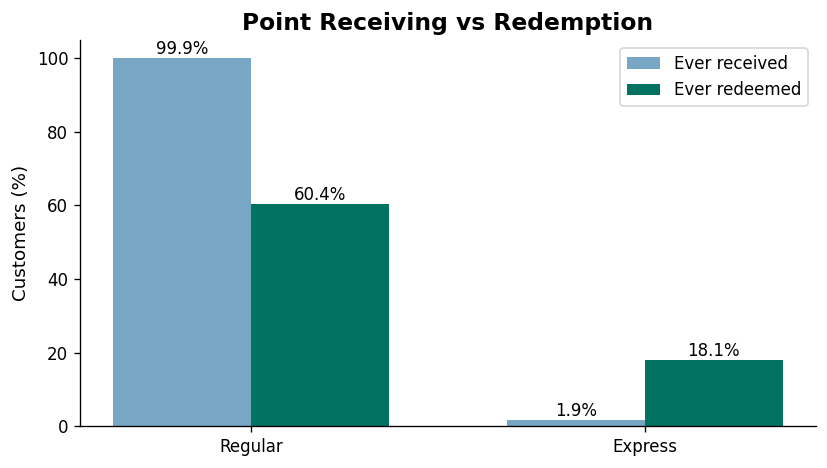

In [492]:
point_types = loyalty_participation["point_type"]
positions = list(range(len(point_types)))
bar_width = 0.35

received_positions = [position - bar_width / 2 for position in positions]

redeemed_positions = [position + bar_width / 2 for position in positions]

plt.figure(figsize=(7, 4))

received_bars = plt.bar(
    received_positions,
    loyalty_participation["ever_received_pct"],
    width=bar_width,
    label="Ever received",
    color=COLORS["serene_sea"],
)

redeemed_bars = plt.bar(
    redeemed_positions,
    loyalty_participation["ever_redeemed_pct"],
    width=bar_width,
    label="Ever redeemed",
    color=COLORS["pacific_green"],
)

for bars in [received_bars,redeemed_bars,]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{bar.get_height():.1f}%",
            ha="center",
            va="bottom",
        )

plt.xticks(positions,point_types,)

plt.title("Point Receiving vs Redemption")
plt.ylabel("Customers (%)")
plt.legend()
plt.tight_layout()
plt.show()

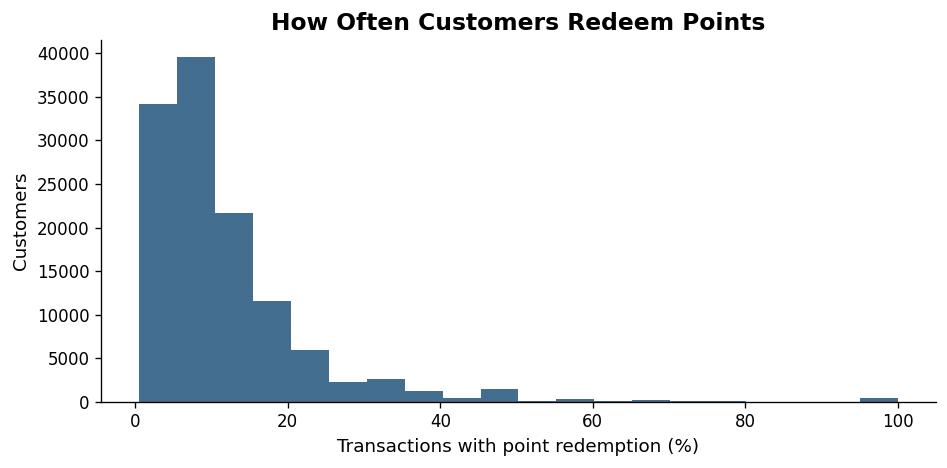

In [493]:
redeeming_customers = customer_loyalty_behavior.loc[customer_loyalty_behavior["any_redemption_transaction_share"] > 0].copy()

plt.figure(figsize=(8, 4))

plt.hist(
    100 * redeeming_customers["any_redemption_transaction_share"],
    bins=20,
    color=COLORS["rainy_lake"],
)

plt.title("How Often Customers Redeem Points")
plt.xlabel("Transactions with point redemption (%)")
plt.ylabel("Customers")
plt.tight_layout()
plt.show()

In [494]:
loyalty_recency_status = pd.Series("Never redeemed",index=customer_loyalty_behavior.index,)

has_redeemed = (customer_loyalty_behavior["redemption_transactions"] > 0)

has_recent_redemption = (customer_loyalty_behavior["redemption_transactions_30d"] > 0)

loyalty_recency_status.loc[has_redeemed & ~has_recent_redemption] = "Redeemed earlier only"

loyalty_recency_status.loc[has_recent_redemption] = "Redeemed in latest 30 days"

loyalty_recency_distribution = (
    loyalty_recency_status
    .value_counts()
    .reindex(
        [
            "Never redeemed",
            "Redeemed earlier only",
            "Redeemed in latest 30 days",
        ],
        fill_value=0,
    )
    .rename_axis("loyalty_status")
    .reset_index(name="customers")
)

loyalty_recency_distribution["percentage"] = (100 * loyalty_recency_distribution["customers"] / loyalty_recency_distribution["customers"].sum())

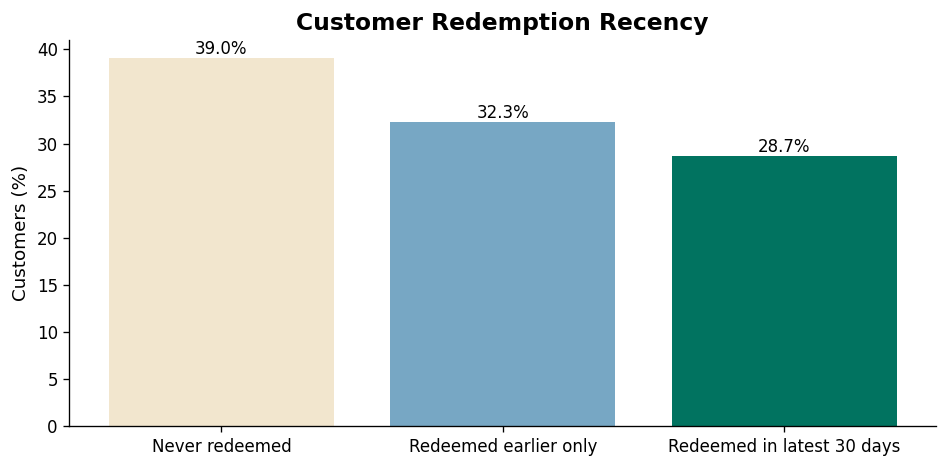

In [495]:
plt.figure(figsize=(8, 4))

bars = plt.bar(
    loyalty_recency_distribution["loyalty_status"],
    loyalty_recency_distribution["percentage"],
    color=[
        COLORS["afterglow"],
        COLORS["serene_sea"],
        COLORS["pacific_green"],
    ],
)

for bar, percentage in zip(bars,loyalty_recency_distribution["percentage"],):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{percentage:.1f}%",
        ha="center",
        va="bottom",
    )

plt.title("Customer Redemption Recency")
plt.ylabel("Customers (%)")
plt.tight_layout()
plt.show()

In [496]:
redemption_context_summary = summarize_metrics(
    customer_loyalty_behavior,
    [
        "redeemed_points_to_spend_ratio",
        "redemption_transaction_value_ratio",
        "redemption_basket_quantity_ratio",
        "days_since_last_redemption",
        "avg_redemption_gap_days",
    ],
)

display(
    style_table(
        redemption_context_summary,
        formats={
            "p25": "{:,.2f}",
            "median": "{:,.2f}",
            "p75": "{:,.2f}",
            "p95": "{:,.2f}",
        },
    )
)

metric,p25,median,p75,p95
redeemed_points_to_spend_ratio,0.00,0.01,0.01,0.03
redemption_transaction_value_ratio,0.54,0.87,1.24,2.04
redemption_basket_quantity_ratio,0.55,0.87,1.21,1.96
days_since_last_redemption,13.00,32.00,67.00,101.00
avg_redemption_gap_days,19.00,31.00,48.00,82.00


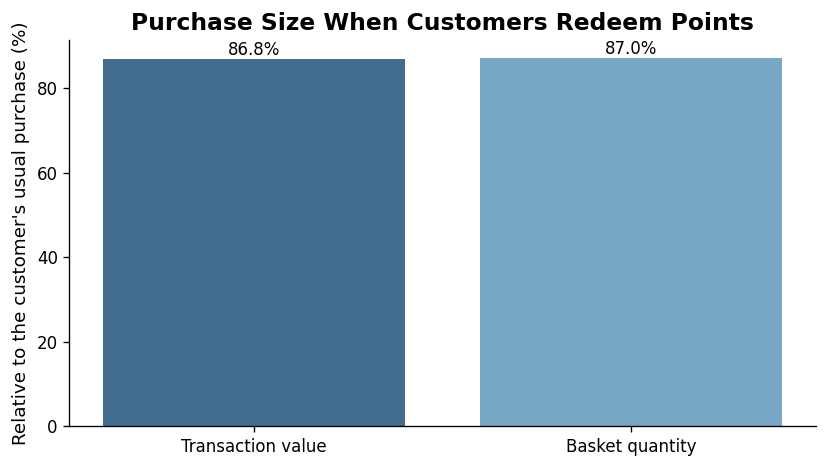

In [497]:
redemption_context = pd.DataFrame({
    "metric": ["Transaction value","Basket quantity",],
    "relative_to_usual_pct": [
        100 * customer_loyalty_behavior["redemption_transaction_value_ratio"].median(),
        100 * customer_loyalty_behavior["redemption_basket_quantity_ratio"].median(),
    ],
})

plt.figure(figsize=(7, 4))

bars = plt.bar(
    redemption_context["metric"],
    redemption_context["relative_to_usual_pct"],
    color=[
        COLORS["rainy_lake"],
        COLORS["serene_sea"],
    ],
)

for bar, value in zip(bars,redemption_context["relative_to_usual_pct"],):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom",
    )

plt.title("Purchase Size When Customers Redeem Points")
plt.ylabel("Relative to the customer's usual purchase (%)")
plt.tight_layout()
plt.show()

- Almost all customers (99.9%) receive regular points, but only 60.4% have ever used them. 

- 39.0% have never redeemed points, 32.3% redeemed them in the past but had no redemption transactions in the last 30 days, and 28.7% continued to use points within the last 30 days. This shows that customers differ not only in whether they use rewards, but also in how recently they use them.

- Even among customers who have redeemed points, reward usage occurs in only a small fraction of their transactions (under 20% of their total orders). Additionally, for those who redeem points multiple times, the average gap between redemption days is up to 31 days.

- When customers redeem points, their basket is typically smaller than normal. Specifically, the order value and the item count are only about 86.8% and 87.0% of their own average purchase. This shows that points are used for regular or slightly smaller shopping trips, rather than being saved for large orders.

- Only 1.9% of customers received express points during the observation period, yet 18.1% had redemption transactions. It is highly likely that many customers had already accumulated an express point balance before the system started recording the purchase history. Therefore, the current data only captures the spending of those older points without showing when they were originally earned.

### Customer Behavioral Summary

- The customer base is active and connected to RetailHero, but behaviors vary significantly.

- These differences span several dimensions: shopping frequency, spending, recent activity levels, product preferences, store choices, and loyalty reward usage.

- A clear pattern emerges: customers combine loyalty with flexibility. They explore various products and stores but consistently return to familiar items and a preferred location. Notably, high shopping activity does not guarantee active loyalty program usage, and some active customers were already slowing down before the campaign.

Overall, there is no single "typical" customer. The pre-treatment behavioral differences suggest that customers will not respond to the same promotion equally.

The next step shifts from pre-campaign behavior to post-campaign outcomes: examining the purchase outcome, the overall Treatment–Control difference, and how this difference varies across behavioral groups.

### Campaign Impact & Treatment–Control Difference

- As verified in the `Experiment Sanity Check`

    - Post-campaign purchasing was generally high, with 62% of all customers making a purchase.

    - To measure the campaign's true impact, we compare the two groups. , the Control group sets the baseline purchase rate at 60.33% (without the SMS), while the Treatment group reached 63.65%. This creates an overall uplift of +3.32 percentage points.

    - While the SMS successfully drove additional sales at the population level, this +3.32 pp average hides significant variations. As our earlier analysis showed, the customer base includes very different types of shoppers—ranging from highly active to slowing customers, and from active reward redeemers to those who rarely use points.

- Therefore, the key question is no longer whether the campaign works on average, but rather:

> Which kinds of customers show a larger or smaller Treatment–Control gap?

## Exploratory Treatment Heterogeneity

The overall Treatment–Control difference is **+3.32 percentage points**, but this is only an average across the full customer population.

The next question is therefore:

> **Does the observed Treatment–Control gap remain similar across these different customer behaviors?**

To explore this, we reuse the customer groups defined in the previous EDA.

The tables below show the purchase rates for both the Control and Treatment customers in each group. The final column calculates the exact difference:

Treatment Purchase Rate − Control Purchase Rate

The charts visually highlight this gap. A dashed line marks the overall average of +3.32 pp. Bars above this line mean the group had a stronger-than-average response to the SMS, while bars below indicate a weaker response.

In [498]:
overall_gap_pp = (
    outcome_by_treatment.loc[
        outcome_by_treatment["experiment_group"] == "Treatment",
        "positive_outcome_rate",
    ].iloc[0]
    - outcome_by_treatment.loc[
        outcome_by_treatment["experiment_group"] == "Control",
        "positive_outcome_rate",
    ].iloc[0]
)

print(
    "Overall Treatment-Control gap:",
    f"{overall_gap_pp:+.2f} pp",
)

Overall Treatment-Control gap: +3.32 pp


In [499]:
customer_heterogeneity = duckdb_connection.execute(
    """
    SELECT
        u.client_id,
        u.treatment_flg,
        u.target,

        core.transaction_count,
        core.total_spend,

        product.favorite_product_share,

        store.unique_stores

    FROM uplift_train AS u

    LEFT JOIN customer_core_behavior AS core
        USING (client_id)

    LEFT JOIN customer_product_behavior AS product
        USING (client_id)

    LEFT JOIN customer_store_behavior AS store
        USING (client_id)

    ORDER BY u.client_id
    """
).df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [500]:
momentum_lookup = customer_core_behavior[["client_id"]].copy()

momentum_lookup["momentum_group"] = momentum_status


loyalty_lookup = customer_loyalty_behavior[["client_id"]].copy()

loyalty_lookup["loyalty_group"] = loyalty_recency_status


customer_heterogeneity = (
    customer_heterogeneity
    .merge(
        momentum_lookup,
        on="client_id",
        how="left",
    )
    .merge(
        loyalty_lookup,
        on="client_id",
        how="left",
    )
)

In [501]:
engagement_thresholds = (
    engagement_summary
    .loc[
        engagement_summary["metric"] == "transaction_count",
        ["p25","median","p75",],
    ]
    .iloc[0]
)

In [502]:
value_thresholds = (
    customer_value_summary
    .loc[
        customer_value_summary["metric"] == "total_spend",
        ["p25","median","p75",],
    ]
    .iloc[0]
)

In [503]:
preference_thresholds = (
    repeat_preference_summary
    .loc[
        repeat_preference_summary["metric"] == "favorite_product_share (%)",
        ["p25","median","p75",],
    ]
    .iloc[0]
    / 100
)

In [504]:
customer_heterogeneity["engagement_group"] = pd.cut(
    customer_heterogeneity["transaction_count"],
    bins=[
        float("-inf"),
        engagement_thresholds["p25"],
        engagement_thresholds["median"],
        engagement_thresholds["p75"],
        float("inf"),
    ],
    labels=[
        "Low frequency",
        "Moderate-low frequency",
        "Moderate-high frequency",
        "High frequency",
    ],
    include_lowest=True,
)

In [505]:
customer_heterogeneity["value_group"] = pd.cut(
    customer_heterogeneity["total_spend"],
    bins=[
        float("-inf"),
        value_thresholds["p25"],
        value_thresholds["median"],
        value_thresholds["p75"],
        float("inf"),
    ],
    labels=[
        "Low value",
        "Moderate-low value",
        "Moderate-high value",
        "High value",
    ],
    include_lowest=True,
)

In [506]:
customer_heterogeneity["preference_group"] = pd.cut(
    customer_heterogeneity["favorite_product_share"],
    bins=[
        float("-inf"),
        preference_thresholds["p25"],
        preference_thresholds["median"],
        preference_thresholds["p75"],
        float("inf"),
    ],
    labels=[
        "Low repeat preference",
        "Moderate-low repeat",
        "Moderate-high repeat",
        "High repeat preference",
    ],
    include_lowest=True,
)

In [507]:
footprint_group = pd.Series("Multi-store",index=customer_heterogeneity.index,)

footprint_group.loc[customer_heterogeneity["unique_stores"] == 1] = "Single-store"

customer_heterogeneity["footprint_group"] = pd.Categorical(
    footprint_group,
    categories=[
        "Single-store",
        "Multi-store",
    ],
    ordered=True,
)

In [508]:
customer_heterogeneity["momentum_group"] = pd.Categorical(
    customer_heterogeneity["momentum_group"],
    categories=[
        "On / ahead of usual pace",
        "Slower than usual",
        "Not enough history",
    ],
    ordered=True,
)

In [509]:
customer_heterogeneity["loyalty_group"] = pd.Categorical(
    customer_heterogeneity["loyalty_group"],
    categories=[
        "Never redeemed",
        "Redeemed earlier only",
        "Redeemed in latest 30 days",
    ],
    ordered=True,
)

In [510]:
def summarize_treatment_gap(
    data: pd.DataFrame,
    group_column: str,
) -> pd.DataFrame:
    """Compare observed purchase rates between Treatment and Control."""

    grouped = (
        data
        .dropna(subset=[group_column])
        .groupby(
            [group_column,"treatment_flg",],
            observed=True,
        )
        .agg(
            customers=("target", "size"),
            purchase_rate=("target", "mean"),
        )
        .reset_index()
    )

    control = (
        grouped.loc[
            grouped["treatment_flg"] == 0,
            [
                group_column,
                "customers",
                "purchase_rate",
            ],
        ]
        .rename(
            columns={
                "customers": "control_customers",
                "purchase_rate": "control_purchase_rate",
            }
        )
    )

    treatment = (
        grouped.loc[
            grouped["treatment_flg"] == 1,
            [
                group_column,
                "customers",
                "purchase_rate",
            ],
        ]
        .rename(
            columns={
                "customers": "treatment_customers",
                "purchase_rate": "treatment_purchase_rate",
            }
        )
    )

    summary = control.merge(
        treatment,
        on=group_column,
        how="inner",
    )

    summary["control_purchase_rate"] *= 100
    summary["treatment_purchase_rate"] *= 100

    summary["observed_gap_pp"] = (
        summary["treatment_purchase_rate"] - summary["control_purchase_rate"]
    )

    return summary

In [511]:
TREATMENT_GAP_FORMATS = {
    "control_customers": "{:,.0f}",
    "treatment_customers": "{:,.0f}",
    "control_purchase_rate": "{:.2f}%",
    "treatment_purchase_rate": "{:.2f}%",
    "observed_gap_pp": "{:+.2f} pp",
}

In [512]:
def plot_treatment_gap(
    summary: pd.DataFrame,
    group_column: str,
    title: str,
    overall_gap_pp: float,
) -> None:
    """Plot subgroup Treatment-Control gaps against the overall gap."""

    plt.figure(figsize=(8, 4))

    bars = plt.barh(
        summary[group_column].astype(str),
        summary["observed_gap_pp"],
        color=COLORS["rainy_lake"],
    )

    plt.axvline(0,linewidth=1,color="black",)

    plt.axvline(
        overall_gap_pp,
        linewidth=1,
        linestyle="--",
        color=COLORS["pacific_green"],
        label=f"Overall gap ({overall_gap_pp:+.2f} pp)",
    )

    for bar, gap in zip(bars,summary["observed_gap_pp"],):
        plt.text(
            gap,
            bar.get_y() + bar.get_height() / 2,
            f" {gap:+.2f} pp",
            va="center",
        )

    plt.title(title)
    plt.xlabel("Treatment - Control purchase rate (pp)")
    plt.legend()
    plt.tight_layout()
    plt.show()

engagement_group,control_customers,control_purchase_rate,treatment_customers,treatment_purchase_rate,observed_gap_pp
Low frequency,"26,711",32.43%,"26,604",36.84%,+4.41 pp
Moderate-low frequency,"24,288",53.33%,"24,089",57.79%,+4.46 pp
Moderate-high frequency,"25,365",71.15%,"25,219",73.57%,+2.42 pp
High frequency,"23,694",87.38%,"24,069",88.77%,+1.39 pp


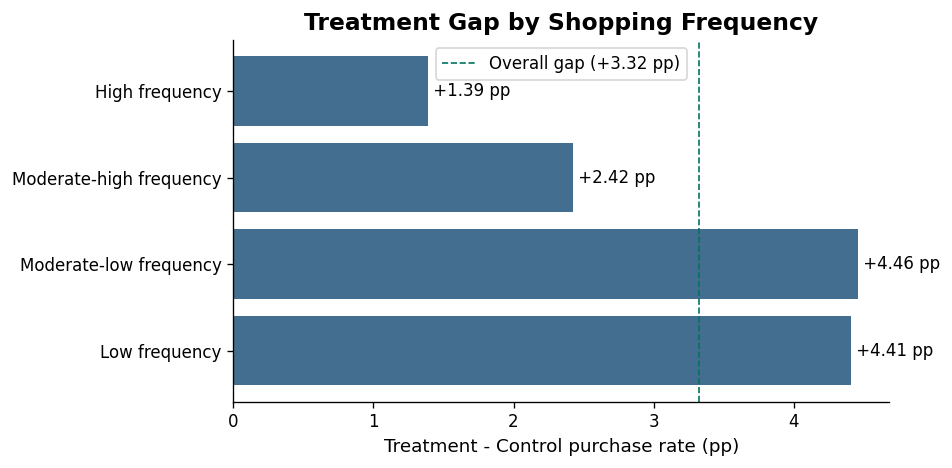

In [513]:
engagement_treatment_gap = summarize_treatment_gap(customer_heterogeneity,"engagement_group",)

display(
    style_table(
        engagement_treatment_gap,
        formats=TREATMENT_GAP_FORMATS,
    )
)

plot_treatment_gap(
    engagement_treatment_gap,
    "engagement_group",
    "Treatment Gap by Shopping Frequency",
    overall_gap_pp,
)

- The Treatment-Control gap decreases as shopping frequency increases. Low-frequency customers show a gap of **+4.41 pp**, while the highest-frequency customers show only **+1.39 pp**.

- At the same time, the Control purchase rate rises from **32.43% to 87.38%**. Customers who already shop very frequently are therefore much more likely to purchase, but their observed SMS gap is much smaller.

value_group,control_customers,control_purchase_rate,treatment_customers,treatment_purchase_rate,observed_gap_pp
Low value,"25,199",37.22%,"24,811",42.45%,+5.23 pp
Moderate-low value,"25,048",55.54%,"24,961",59.08%,+3.54 pp
Moderate-high value,"24,887",68.47%,"25,123",71.39%,+2.92 pp
High value,"24,924",80.38%,"25,086",81.42%,+1.04 pp


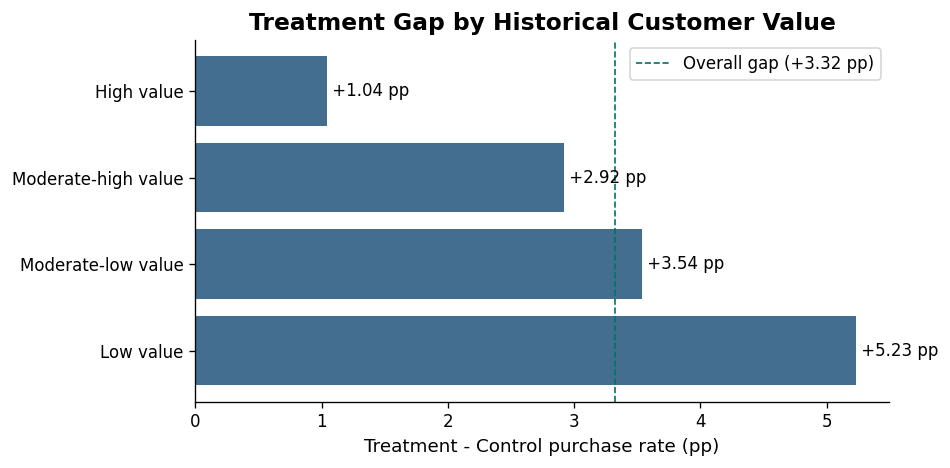

In [514]:
value_treatment_gap = summarize_treatment_gap(customer_heterogeneity,"value_group",)

display(
    style_table(
        value_treatment_gap,
        formats=TREATMENT_GAP_FORMATS,
    )
)

plot_treatment_gap(
    value_treatment_gap,
    "value_group",
    "Treatment Gap by Historical Customer Value",
    overall_gap_pp,
)

- Customer value shows an even stronger pattern. The observed gap falls steadily from **+5.23 pp for low-value customers** to only **+1.04 pp for the highest-value customers**.

- Meanwhile, the Control purchase rate increases from **37.22% to 80.38%**. The strongest historical customers already purchase at a high rate even without the SMS.

momentum_group,control_customers,control_purchase_rate,treatment_customers,treatment_purchase_rate,observed_gap_pp
On / ahead of usual pace,"73,739",62.78%,"73,434",66.06%,+3.28 pp
Slower than usual,"24,247",56.65%,"24,534",59.90%,+3.25 pp
Not enough history,"2,072",16.12%,"2,013",21.41%,+5.29 pp


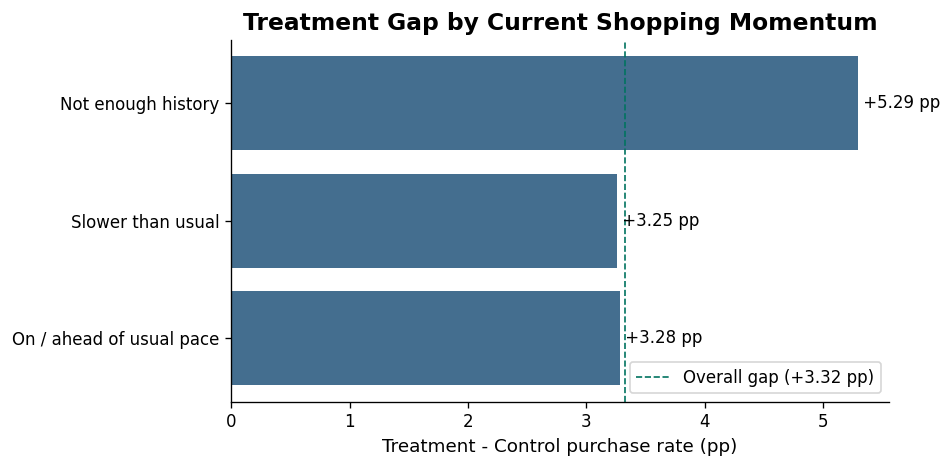

In [515]:
momentum_treatment_gap = summarize_treatment_gap(customer_heterogeneity,"momentum_group",)

display(
    style_table(
        momentum_treatment_gap,
        formats=TREATMENT_GAP_FORMATS,
    )
)

plot_treatment_gap(
    momentum_treatment_gap,
    "momentum_group",
    "Treatment Gap by Current Shopping Momentum",
    overall_gap_pp,
)

- Customers who remain on their normal shopping pace and customers who are slowing down show almost identical gaps: **+3.28 pp and +3.25 pp**.

- The small `Not enough history` group shows a larger **+5.29 pp** gap, but it contains far fewer customers, so this result should be interpreted cautiously.

preference_group,control_customers,control_purchase_rate,treatment_customers,treatment_purchase_rate,observed_gap_pp
Low repeat preference,"26,796",68.15%,"26,853",71.82%,+3.67 pp
Moderate-low repeat,"23,393",63.14%,"23,115",66.49%,+3.35 pp
Moderate-high repeat,"25,060",58.40%,"25,015",61.62%,+3.22 pp
High repeat preference,"24,809",51.18%,"24,998",54.29%,+3.11 pp


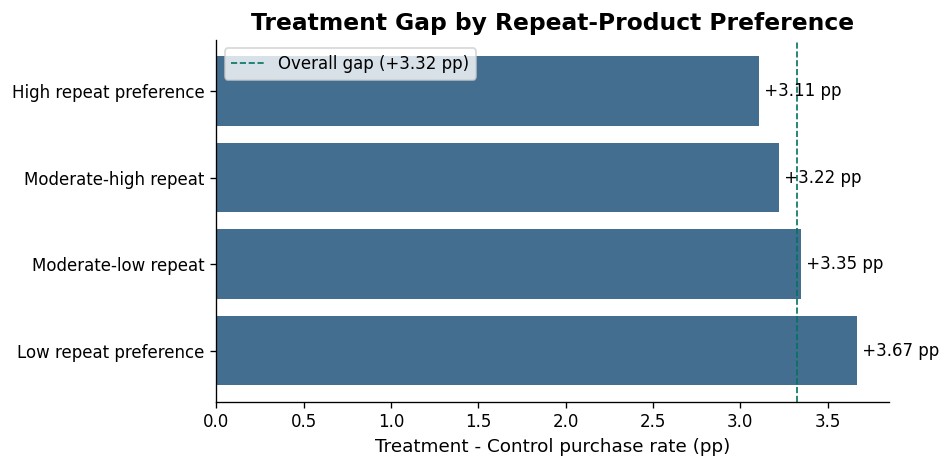

In [516]:
preference_treatment_gap = summarize_treatment_gap(customer_heterogeneity,"preference_group",)

display(
    style_table(
        preference_treatment_gap,
        formats=TREATMENT_GAP_FORMATS,
    )
)

plot_treatment_gap(
    preference_treatment_gap,
    "preference_group",
    "Treatment Gap by Repeat-Product Preference",
    overall_gap_pp,
)

- Treatment-Control gaps remain fairly stable across repeat-product preference groups, ranging only from **+3.11 pp to +3.67 pp**.

- Baseline purchase rates vary much more than the treatment gaps, suggesting that repeat-product preference is strongly related to shopping behavior but shows little visible treatment heterogeneity here.

footprint_group,control_customers,control_purchase_rate,treatment_customers,treatment_purchase_rate,observed_gap_pp
Single-store,"24,960",52.00%,"24,976",56.50%,+4.50 pp
Multi-store,"75,098",63.10%,"75,005",66.03%,+2.94 pp


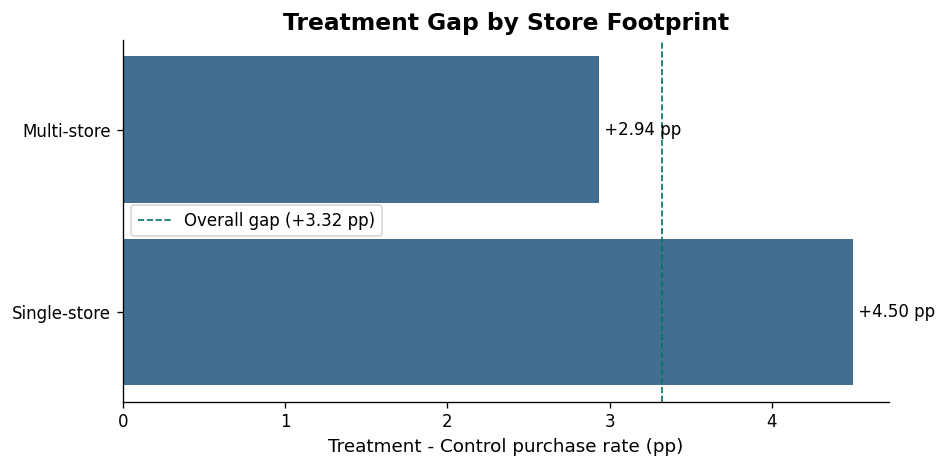

In [517]:
footprint_treatment_gap = summarize_treatment_gap(customer_heterogeneity,"footprint_group",)

display(
    style_table(
        footprint_treatment_gap,
        formats=TREATMENT_GAP_FORMATS,
    )
)

plot_treatment_gap(
    footprint_treatment_gap,
    "footprint_group",
    "Treatment Gap by Store Footprint",
    overall_gap_pp,
)

- Single-store customers show a **+4.50 pp** Treatment-Control gap, compared with **+2.94 pp** for multi-store customers.

- This **1.56 pp difference** is more visible than the differences found for Momentum or Shopping Preference, making store footprint one of the more interesting patterns in this analysis.

loyalty_group,control_customers,control_purchase_rate,treatment_customers,treatment_purchase_rate,observed_gap_pp
Never redeemed,"39,199",50.22%,"38,900",53.31%,+3.09 pp
Redeemed earlier only,"32,208",65.27%,"32,418",68.54%,+3.27 pp
Redeemed in latest 30 days,"28,651",68.60%,"28,663",72.16%,+3.56 pp


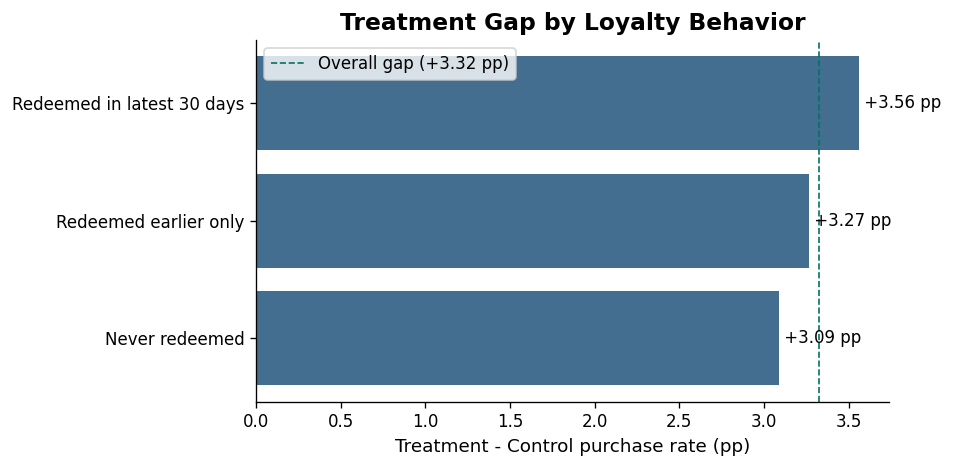

In [518]:
loyalty_treatment_gap = summarize_treatment_gap(customer_heterogeneity,"loyalty_group",)

display(
    style_table(
        loyalty_treatment_gap,
        formats=TREATMENT_GAP_FORMATS,
    )
)

plot_treatment_gap(
    loyalty_treatment_gap,
    "loyalty_group",
    "Treatment Gap by Loyalty Behavior",
    overall_gap_pp,
)

- The observed gap increases slightly with more recent reward usage: **+3.09 pp** for customers who never redeemed, **+3.27 pp** for past redeemers, and **+3.56 pp** for recent redeemers.

- However, the total spread is only **0.47 pp**, while baseline purchase rates differ much more strongly across loyalty groups. Loyalty activity therefore shows only modest treatment heterogeneity in this view.

In [519]:
heterogeneity_overview = pd.concat(
    [
        engagement_treatment_gap.assign(
            behavior_family="Engagement",
            customer_group=lambda data: (
                data["engagement_group"].astype(str)
            ),
        ),
        value_treatment_gap.assign(
            behavior_family="Customer Value",
            customer_group=lambda data: (
                data["value_group"].astype(str)
            ),
        ),
        momentum_treatment_gap.assign(
            behavior_family="Current Momentum",
            customer_group=lambda data: (
                data["momentum_group"].astype(str)
            ),
        ),
        preference_treatment_gap.assign(
            behavior_family="Shopping Preference",
            customer_group=lambda data: (
                data["preference_group"].astype(str)
            ),
        ),
        footprint_treatment_gap.assign(
            behavior_family="Shopping Footprint",
            customer_group=lambda data: (
                data["footprint_group"].astype(str)
            ),
        ),
        loyalty_treatment_gap.assign(
            behavior_family="Loyalty Behavior",
            customer_group=lambda data: (
                data["loyalty_group"].astype(str)
            ),
        ),
    ],
    ignore_index=True,
)

heterogeneity_overview = heterogeneity_overview[
    [
        "behavior_family",
        "customer_group",
        "control_customers",
        "treatment_customers",
        "control_purchase_rate",
        "treatment_purchase_rate",
        "observed_gap_pp",
    ]
]

display(
    style_table(
        heterogeneity_overview,
        formats=TREATMENT_GAP_FORMATS,
    )
)

behavior_family,customer_group,control_customers,treatment_customers,control_purchase_rate,treatment_purchase_rate,observed_gap_pp
Engagement,Low frequency,"26,711","26,604",32.43%,36.84%,+4.41 pp
Engagement,Moderate-low frequency,"24,288","24,089",53.33%,57.79%,+4.46 pp
Engagement,Moderate-high frequency,"25,365","25,219",71.15%,73.57%,+2.42 pp
Engagement,High frequency,"23,694","24,069",87.38%,88.77%,+1.39 pp
Customer Value,Low value,"25,199","24,811",37.22%,42.45%,+5.23 pp
Customer Value,Moderate-low value,"25,048","24,961",55.54%,59.08%,+3.54 pp
Customer Value,Moderate-high value,"24,887","25,123",68.47%,71.39%,+2.92 pp
Customer Value,High value,"24,924","25,086",80.38%,81.42%,+1.04 pp
Current Momentum,On / ahead of usual pace,"73,739","73,434",62.78%,66.06%,+3.28 pp
Current Momentum,Slower than usual,"24,247","24,534",56.65%,59.90%,+3.25 pp


### Treatment Heterogeneity Summary

The overall Treatment-Control gap is **+3.32 pp**, but the subgroup analysis shows that this average is not distributed equally across all customer behaviors.

The clearest differences appear in **shopping frequency, historical customer value, and store footprint**. In contrast, **Current Momentum, Shopping Preference, and Loyalty Behavior** show much smaller changes in the observed gap across their main customer groups.

These results are still exploratory. They show where treatment heterogeneity may exist, but the differences need further statistical validation before being used to support feature-engineering decisions.

### Main Patterns

**Pattern 1: Familiar customers appear to respond less to the SMS.** 

People who shop frequently and spend a lot are already buying on their own. Sending them a message does not seem to stimulate much extra purchasing. The observed campaign impact on this group is very low.

**Pattern 2: Store footprint also separates customer response.**

Single-store shoppers appear easier to convert. Customers who stick to one familiar store seem to respond to the SMS better than those who shop around at multiple locations.

**Pattern 3: Some behaviors change purchase likelihood much more than treatment response.**

Shopping habits do not appear to change SMS effectiveness. What items customers like to buy or whether they use reward points does not show a clear effect on how they react to the message.

**Pattern 4: Recent slowdown does not appear to change the treatment gap much.**

Recent shopping pace does not seem to matter here. Whether customers are shopping steadily or starting to visit less often, their observed decision to buy after receiving the SMS looks almost exactly the same.

In short: Based on current data, the SMS appears to work best and generate the most additional sales from customers who shop less often and visit only one store, rather than from VIPs or highly active shoppers.

### Statistical Reliability of Treatment Heterogeneity

The previous analysis found differences in how customer groups responded to the SMS. However, these are just initial estimates and might be caused by random chance.

This section uses statistical tests to confirm whether the campaign impact truly changes across different customer behaviors.

For each behavior family, we fit a probability model:
$$ target \sim treatment + group + treatment \times group $$

The test focuses directly on whether the interaction between the treatment and the group is real.
*   **H0:** The SMS impact is exactly the same across all groups.
*   **H1:** The SMS impact is different for at least one group.

To ensure accuracy, we apply standard statistical corrections (HC3 robust standard errors and Benjamini-Hochberg FDR). These adjustments keep our estimates reliable when dealing with Yes/No purchase data and prevent false conclusions when testing multiple behaviors at once. 

We also include 95% confidence intervals to show the margin of error for each group. Ultimately, this test determines if the different responses we saw earlier are mathematically real.

In [520]:
import statsmodels.formula.api as smf

from statsmodels.stats.multitest import multipletests

In [521]:
def test_treatment_heterogeneity(
    data: pd.DataFrame,
    group_column: str,
) -> dict:
    """Test whether the treatment effect differs across customer groups."""

    analysis_data = data[["target","treatment_flg",group_column,]].dropna().copy()

    model = smf.ols(
        f"target ~ treatment_flg * C({group_column})",
        data=analysis_data,
    ).fit(cov_type="HC3")

    interaction_terms = [
        term
        for term in model.params.index
        if f"treatment_flg:C({group_column})" in term
    ]

    if not interaction_terms:
        raise ValueError(
            f"No treatment interaction terms found for {group_column}."
        )

    restriction = np.zeros(
        (
            len(interaction_terms),
            len(model.params),
        )
    )

    for row_index, term in enumerate(interaction_terms):
        restriction[row_index,model.params.index.get_loc(term),] = 1.0

    wald_test = model.wald_test(
        restriction,
        scalar=True,
    )

    return {
        "group_column": group_column,
        "customers": len(analysis_data),
        "groups": analysis_data[group_column].nunique(),
        "interaction_df": len(interaction_terms),
        "wald_chi2": float(wald_test.statistic),
        "p_value": float(wald_test.pvalue),
    }

In [522]:
HETEROGENEITY_TESTS = [
    ("Engagement", "engagement_group"),
    ("Customer Value", "value_group"),
    ("Current Momentum", "momentum_group"),
    ("Shopping Preference", "preference_group"),
    ("Shopping Footprint", "footprint_group"),
    ("Loyalty Behavior", "loyalty_group"),
]

In [523]:
heterogeneity_test_results = pd.DataFrame(
    [
        {
            "behavior_family": behavior_family,
            **test_treatment_heterogeneity(
                customer_heterogeneity,
                group_column,
            ),
        }
        for behavior_family, group_column
        in HETEROGENEITY_TESTS
    ]
)

In [524]:
reject_fdr, p_value_fdr, _, _ = multipletests(
    heterogeneity_test_results["p_value"],
    alpha=0.05,
    method="fdr_bh",
)

heterogeneity_test_results["p_value_fdr_bh"] = p_value_fdr

heterogeneity_test_results["significant_fdr_0_05"] = reject_fdr


In [525]:
display(
    style_table(
        heterogeneity_test_results[
            [
                "behavior_family",
                "customers",
                "groups",
                "interaction_df",
                "wald_chi2",
                "p_value",
                "p_value_fdr_bh",
                "significant_fdr_0_05",
            ]
        ],
        formats={
            "customers": "{:,.0f}",
            "groups": "{:,.0f}",
            "interaction_df": "{:,.0f}",
            "wald_chi2": "{:.2f}",
            "p_value": "{:.3g}",
            "p_value_fdr_bh": "{:.3g}",
        },
    )
)

behavior_family,customers,groups,interaction_df,wald_chi2,p_value,p_value_fdr_bh,significant_fdr_0_05
Engagement,"200,039",4,3,52.34,2.54e-11,7.61e-11,True
Customer Value,"200,039",4,3,58.55,1.2e-12,7.2e-12,True
Current Momentum,"200,039",3,2,2.65,0.266,0.399,False
Shopping Preference,"200,039",4,3,1.02,0.796,0.796,False
Shopping Footprint,"200,039",2,1,9.41,0.00216,0.00431,True
Loyalty Behavior,"200,039",3,2,0.83,0.66,0.792,False


In [526]:
def summarize_subgroup_effects(
    data: pd.DataFrame,
    group_column: str,
) -> pd.DataFrame:
    """Estimate subgroup Treatment-Control gaps with HC3 confidence intervals."""

    observed_groups = data[group_column].dropna().drop_duplicates().tolist()

    if isinstance(
        data[group_column].dtype,
        pd.CategoricalDtype,
    ):
        observed_groups = [
            group
            for group in data[group_column].cat.categories
            if group in observed_groups
        ]

    rows = []

    for group in observed_groups:
        group_data = data.loc[data[group_column] == group,["target","treatment_flg",],].dropna().copy()

        model = smf.ols(
            "target ~ treatment_flg",
            data=group_data,
        ).fit(cov_type="HC3")

        ci_low, ci_high = model.conf_int().loc["treatment_flg"]

        rows.append(
            {
                "customer_group": str(group),
                "customers": len(group_data),
                "effect_pp": (100* model.params["treatment_flg"]),
                "ci_low_pp": 100 * ci_low,
                "ci_high_pp": 100 * ci_high,
            }
        )

    return pd.DataFrame(rows)

In [527]:
subgroup_effect_ci = pd.concat(
    [
        summarize_subgroup_effects(customer_heterogeneity,group_column,).assign(behavior_family=behavior_family)
        for behavior_family, group_column
        in HETEROGENEITY_TESTS
    ],
    ignore_index=True,
)

subgroup_effect_ci = subgroup_effect_ci[
    [
        "behavior_family",
        "customer_group",
        "customers",
        "effect_pp",
        "ci_low_pp",
        "ci_high_pp",
    ]
]

In [528]:
display(
    style_table(
        subgroup_effect_ci,
        formats={
            "customers": "{:,.0f}",
            "effect_pp": "{:+.2f} pp",
            "ci_low_pp": "{:+.2f} pp",
            "ci_high_pp": "{:+.2f} pp",
        },
    )
)

behavior_family,customer_group,customers,effect_pp,ci_low_pp,ci_high_pp
Engagement,Low frequency,"53,315",+4.41 pp,+3.60 pp,+5.22 pp
Engagement,Moderate-low frequency,"48,377",+4.46 pp,+3.57 pp,+5.34 pp
Engagement,Moderate-high frequency,"50,584",+2.42 pp,+1.64 pp,+3.20 pp
Engagement,High frequency,"47,763",+1.39 pp,+0.81 pp,+1.97 pp
Customer Value,Low value,"50,010",+5.23 pp,+4.38 pp,+6.09 pp
Customer Value,Moderate-low value,"50,009",+3.54 pp,+2.67 pp,+4.41 pp
Customer Value,Moderate-high value,"50,010",+2.92 pp,+2.12 pp,+3.73 pp
Customer Value,High value,"50,010",+1.04 pp,+0.35 pp,+1.73 pp
Current Momentum,On / ahead of usual pace,"147,173",+3.28 pp,+2.79 pp,+3.77 pp
Current Momentum,Slower than usual,"48,781",+3.25 pp,+2.38 pp,+4.13 pp


### Statistical Testing Findings

The statistical tests simply confirm whether the patterns we saw earlier are mathematically real or just random luck.

**1. These patterns are real (Statistically Significant):**
*   **Customer Value and Engagement:** The math highly confirms that low-spending and less frequent shoppers respond much better to the SMS. This is a proven rule, not a coincidence.
*   **Store Footprint:** The test also confirms that single-store shoppers are genuinely easier to influence than multi-store shoppers.

**2. These patterns are just noise (Not Significant):**
*   **Momentum, Preference, and Loyalty:** The math shows no real difference here. Any slight variations in response rates across these groups were just random chance. The SMS does not work differently based on what people buy, how they use points, or their recent shopping pace.

### Heterogeneity Testing Summary

We have now mathematically confirmed which behaviors actually change how customers respond to the campaign: Engagement, Customer Value, and Store Footprint. The rule is clear: less active and single-store shoppers are the easiest to influence.

This completes our exploratory testing. We now know what drives the SMS effectiveness, but these insights alone are not the final model. The next step is to take these proven signals and build our machine learning model to predict individual customer uplift.

## EDA Conclusion and Handoff

Customer behavior was explored across engagement, historical value, current momentum, product preference, store footprint, and loyalty activity. The subsequent heterogeneity tests provided statistical support for treatment-effect differences across:

- **Engagement**
- **Customer Value**
- **Shopping Footprint**

Current Momentum, Shopping Preference, and Loyalty Behavior did not show clear statistical evidence of heterogeneous treatment response in the current subgroup tests.

These results are used as guidance for the next stage rather than as final feature-selection decisions.

The EDA-specific behavioral groups are not exported as features.

The resulting table is therefore the **input to feature engineering**, not the final modeling dataset.

In [529]:
duckdb_connection.execute(
    """
    CREATE OR REPLACE VIEW retailhero_customer_base AS

    SELECT
        u.client_id,

        c.* EXCLUDE (client_id),

        core.* EXCLUDE (client_id),

        product.* EXCLUDE (client_id),

        store.* EXCLUDE (client_id),

        loyalty.* EXCLUDE (client_id),

        u.treatment_flg,
        u.target

    FROM uplift_train AS u

    LEFT JOIN clients AS c
        USING (client_id)

    LEFT JOIN customer_core_behavior AS core
        USING (client_id)

    LEFT JOIN customer_product_behavior AS product
        USING (client_id)

    LEFT JOIN customer_store_behavior AS store
        USING (client_id)

    LEFT JOIN customer_loyalty_behavior AS loyalty
        USING (client_id)

    ORDER BY u.client_id
    """
)

In [530]:
customer_base_check = duckdb_connection.execute(
    """
    SELECT
        COUNT(*) AS rows,
        COUNT(DISTINCT client_id) AS unique_customers,
        SUM(client_id IS NULL) AS missing_client_id,
        SUM(treatment_flg IS NULL) AS missing_treatment,
        SUM(target IS NULL) AS missing_target
    FROM retailhero_customer_base
    """
).df()

display(customer_base_check)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,rows,unique_customers,missing_client_id,missing_treatment,missing_target
0,200039,200039,0.0000,0.0000,0.0000


In [531]:
assert customer_base_check.loc[0, "rows"] == 200_039
assert customer_base_check.loc[0, "unique_customers"] == 200_039
assert customer_base_check.loc[0, "missing_client_id"] == 0
assert customer_base_check.loc[0, "missing_treatment"] == 0
assert customer_base_check.loc[0, "missing_target"] == 0

In [532]:
customer_base_schema = duckdb_connection.execute(
    """
    DESCRIBE retailhero_customer_base
    """
).df()

display(customer_base_schema)

,column_name,column_type,null,key,default,extra
0,client_id,VARCHAR,YES,None,None,None
1,first_issue_date,TIMESTAMP,YES,None,None,None
2,first_redeem_date,TIMESTAMP,YES,None,None,None
3,age,BIGINT,YES,None,None,None
4,gender,VARCHAR,YES,None,None,None
5,recency_days,BIGINT,YES,None,None,None
6,transaction_count,BIGINT,YES,None,None,None
7,active_days,BIGINT,YES,None,None,None
8,total_spend,DOUBLE,YES,None,None,None
9,avg_transaction_value,DOUBLE,YES,None,None,None


In [533]:
CUSTOMER_BASE_PATH = INTERIM_DATA_DIR / "retailhero_customer_base.parquet"


duckdb_connection.execute(
    f"""
    COPY retailhero_customer_base
    TO '{CUSTOMER_BASE_PATH.as_posix()}'
    (
        FORMAT PARQUET,
        COMPRESSION ZSTD
    )
    """
)

print("Customer base saved:", CUSTOMER_BASE_PATH)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Customer base saved: d:\thao\d\uplif_model\uplif_customer_selection\data\interim\retailhero\retailhero_customer_base.parquet


In [534]:
export_check = duckdb_connection.execute(
    f"""
    SELECT
        COUNT(*) AS rows,
        COUNT(DISTINCT client_id) AS unique_customers
    FROM read_parquet(
        '{CUSTOMER_BASE_PATH.as_posix()}'
    )
    """
).df()

display(export_check)

,rows,unique_customers
0,200039,200039
